# Abstract

This study is based on solar power prediction, where we will find the pattern between weather and ac power generation. In 1839, the ability of some materials to create an electrical charge from light was first observed by the French physicist Edmond Becquerel. Those were too inefficient for simple electric devices. Later on it was changed by hitting selenium. Based on this theory, in 1876, William Grylls Adams and Richard Evans Day published "The action of light on selenium 1876. Later on based on further development, instead of a single cell, we use multiple arrays of solar cells, which are used mostly in households and offices as a part of clean energy resources. This study focuses on the United Nations Sustainable Development Goal 7: Affordable and Clean Energy, addressing the global need for efficient and clean power sources. We know that there are a bunch of factors that affect the productivity of AC power for a solar panel which include irradiation, module temperature and ambient temperature. The global expansion of solar photovoltaics is central of achieving a sustainable energy transition, where governments are aiming to triple renewable energy capacity by 2030. Solar PV deployment is increasing in diverse climates beyond traditional mid-latitude regions, where environmental factors such as temperature, aerosols, and atmospheric conditions significantly influence energy output. Here, we will work on the Solar Power generation data from Kaggle to predict the impact of weather variables on solar power production, and we will optimize performance on our machine learning model. Key variables are solar irradiance variability, ambient temperature, and module temperature. As we will predict the power output so our model will be a regression model. By addressing environmental challenges, this research contributes to enhancing PV efficiency and advancement in global sustainable goals. 
   

# Dataset Collection

This data has been gathered at two solar power plants in India over a 34-day period. Each dataset has 2 pair of files, one is the power generation and another is the sensor reading dataset. Later on in the study, we will merge these 2 datasets and use this to perform prediction for solar power generation prediction. For collecting the sensor data, the data was gathered at a plant level, which was placed optimally. 
This dataset is kaggle gold standard, which means it is a very high quality and also the data was taken from either in real world application or from lab environment, not from simulation, also it avoids garbage in and garbage out problem.  

# Stakeholders and Audiences

This study finding will benefit mostly energy companies and also environmental organizations. The usage of machine learning algorithm has increased drastically in the power sectors. Like we will find so many examples that predicts wind power generation, grid based power production prediction. 
Also, these days a lot of companies are focusing on developing the goal of zero carbon emission like Apple , Microsoft, Toyota, Volkswagen. Developing a solar panel on the top of the factory is a modern approach. They can benefit from this study. This practice not only contributes to corporate environmental responsibility but also focuses global efforts to transition toward renewable energy and meet climate targets.  

Here are some factors that will benefit the Stakeholders : 

* Solar power forecasting will allow companies to plan energy storage and grid distribution, also it helps to reduce the waste and improve reliability
* Cost-effective solution as it helps to reduce the usage of heavy machines to predict power output
* If the prediction is reliable, it helps to support a decision on where to invest, based on the optimum temperature, sunlight we can create the solar plant in a perfect place for optimum output
* Data-driven insights strengthen campaigns for clean energy adoption
* Businesses can plan operations around predicted energy availability, reducing reliance on expensive non-renewable sources. 

# Research Questions

The research question of my interest
Data & environmental understanding
* RQ1: Which environmental factors most strongly influence solar power generation?
* RQ4: How does power generation vary across different timestamps?

Modelling approach & dataset design
* RQ3: Which regression model types are most suitable for this solar power dataset?
* RQ6: What train–validation–test split strategy is most appropriate for this time‑series solar dataset?
* RQ7: Which features can be removed without harming performance, and which features are most useful for prediction (feature importance/selection)?

Model performance & robustness
* RQ2: How accurately can the selected models predict solar power output on unseen data?
* RQ5: Can the chosen models reliably capture and track short‑term fluctuations in power generation at different timestamps?
* RQ9: Can the models accurately forecast solar power generation for the next few days to support grid management?

Operational insights & stakeholder value
* RQ8: How can predictive solar power generation models help stakeholders optimise energy planning and grid management?
* RQ10: Can the model outputs be used to identify when solar panels require cleaning or maintenance?
* RQ11: Can the models detect faulty or sub‑optimally performing equipment (e.g., underperforming inverters or strings)?

# Libraries

Before importing the libraries we need to make sure that those are already installed

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
!pip install torch
!pip install Optuna
!pip install xgboost
!pip install ipywidgets

In [134]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor
from xgboost import DMatrix
# For pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
# For widgets
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
# For Statistical analysis
from scipy import stats
from scipy.stats import f_oneway, ttest_rel
from scipy.stats import friedmanchisquare
import joblib


# Util function

In [4]:
# Util
# In this section, we define reusable helper code for the project.
# Purpose of this function is to split train test based on unique dates
def split_and_scale_by_date(df, date_col="DATE", feature_cols=None, target_col="AC_POWER", split_ratio=0.8,random_state=42):
    """
    Here, we will split the data frame into training and testing sets by unique dates and apply MinMax scaling.

    Returns: X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scaler
    """
    if feature_cols is None:
        raise ValueError("feature_cols must be provided as a list of column names.")

    # 1. Unique dates
    unique_dates = df[date_col].drop_duplicates().values

    # 2. Shuffle dates (reproducible)
    rng = np.random.RandomState(random_state)
    rng.shuffle(unique_dates)

    # 3. Split dates into train/test
    split_index = int(len(unique_dates) * split_ratio)
    train_dates = unique_dates[:split_index]
    test_dates = unique_dates[split_index:]

    # 4. Select rows for each set
    train_df = df[df[date_col].isin(train_dates)].copy()
    test_df = df[df[date_col].isin(test_dates)].copy()

    # 5. Initialize scalers
    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    # 6. Fit on training data only
    X_train = X_scaler.fit_transform(train_df[feature_cols])
    y_train = y_scaler.fit_transform(train_df[[target_col]])

    # 7. Transform test data
    X_test = X_scaler.transform(test_df[feature_cols])
    y_test = y_scaler.transform(test_df[[target_col]])

    return X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scalery


def group_kfold_split_by_date(
    df,
    date_col="DATE",
    feature_cols=None,
    target_col="AC_POWER",
    n_splits=5
):
    """
    Performs Group K-Fold CV splitting based on unique dates.
    Returns a generator yielding:
        X_train, X_test, y_train, y_test,
        train_df, test_df, X_scaler, y_scaler
    """
    
    if feature_cols is None:
        raise ValueError("feature_cols must be provided as a list of column names.")
    
    # Group ID = each unique date
    df = df.copy()
    df["GROUP"] = df[date_col].astype(str)

    groups = df["GROUP"].values
    X_all = df[feature_cols].values
    y_all = df[target_col].values.reshape(-1, 1)

    gkf = GroupKFold(n_splits=n_splits)

    fold = 1
    for train_idx, test_idx in gkf.split(X_all, y_all, groups):

        # Raw data splits
        train_df = df.iloc[train_idx].copy()
        test_df  = df.iloc[test_idx].copy()

        # Extract arrays
        X_train_raw = X_all[train_idx]
        y_train_raw = y_all[train_idx]

        X_test_raw  = X_all[test_idx]
        y_test_raw  = y_all[test_idx]

        # Scaling on training only
        X_scaler = MinMaxScaler()
        y_scaler = MinMaxScaler()

        X_train = X_scaler.fit_transform(X_train_raw)
        y_train = y_scaler.fit_transform(y_train_raw)

        X_test = X_scaler.transform(X_test_raw)
        y_test = y_scaler.transform(y_test_raw)

        yield {
            "fold": fold,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "train_df": train_df,
            "test_df": test_df,
            "X_scaler": X_scaler,
            "y_scaler": y_scaler
        }

        fold += 1



# Data Analysis

## Ethical Consideration

When considering this dataset for prediction of Solar Power generation there are several factors that was considered. First the provacy and consent concern are minimal one of the reason is this is technical data also it does not contain any personal information. However there may be a chance of biasness for specific geography region. This dataset was developed from India for specific time not across the whole year. So country and season wise the condition may vary. The risk of potential misuse must be acknowledged, predictions should be applied to improve energy planning rather than exploitive purposes.
One thing to consider in here that the project focuses on one of the UN Sustainable Development Goal, which is the usage of renewable energy that reinforces the ethical foundation by promoting sustainability. 

## Data Loading Code

Here we have 2 csv file now for each plant data
1 : Plant Generation
2 : Plant Weather Sensor data

In [5]:
# Loading power generation data in df_power_generation and weather sensor data in df_weather_sensor
df_power_generation = pd.read_csv('Plant_Generation_Data.csv')
df_weather_sensor = pd.read_csv('Plant_Weather_Sensor_Data.csv')

In [6]:
# Now we will see the different data in here
# Loading power generation head
df_power_generation.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [7]:
# Loading weather sensor head
df_weather_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## The Goal

As there are 2 different datasets at first we will analyze which data is necessary and which data is not required. We will also try to find missing values. If there are any missing values or duplicate values available we will clean the dataset. We may have to target merging the dataset and unify into one before processing into exploratory data analysis (EDA). 

## Dataset Cleaning and Preprocessing

In [8]:
# Here we will load power generation data from tail 
df_power_generation.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [9]:
# Here we will load weather sensor data from tail 
df_weather_sensor.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0
3181,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


From the power generation data frame we can say that multiple data was recorded for each time stamp. Now we will see how many datas are available in specific sample timestamp.

In [10]:
# Finding the unique number of values taken

df_power_generation['DATE_TIME'] = pd.to_datetime(
    df_power_generation['DATE_TIME'], format="%d-%m-%Y %H:%M"
)

# Filter date range
mask = (df_power_generation['DATE_TIME'] >= "2020-05-15") & \
       (df_power_generation['DATE_TIME'] <= "2020-06-17")

df_filtered = df_power_generation[mask]

# Group by DATE_TIME and count unique SOURCE_KEY
result = (
    df_filtered.groupby('DATE_TIME')['SOURCE_KEY']
    .nunique()
    .reset_index()
    .rename(columns={'SOURCE_KEY': 'unique_SOURCE_KEYs'})
)

result


,DATE_TIME,unique_SOURCE_KEYs
0,2020-05-15 00:00:00,21
1,2020-05-15 00:15:00,21
2,2020-05-15 00:30:00,21
3,2020-05-15 00:45:00,21
4,2020-05-15 01:00:00,22
...,...,...
3060,2020-06-16 23:00:00,22
3061,2020-06-16 23:15:00,22
3062,2020-06-16 23:30:00,22
3063,2020-06-16 23:45:00,22


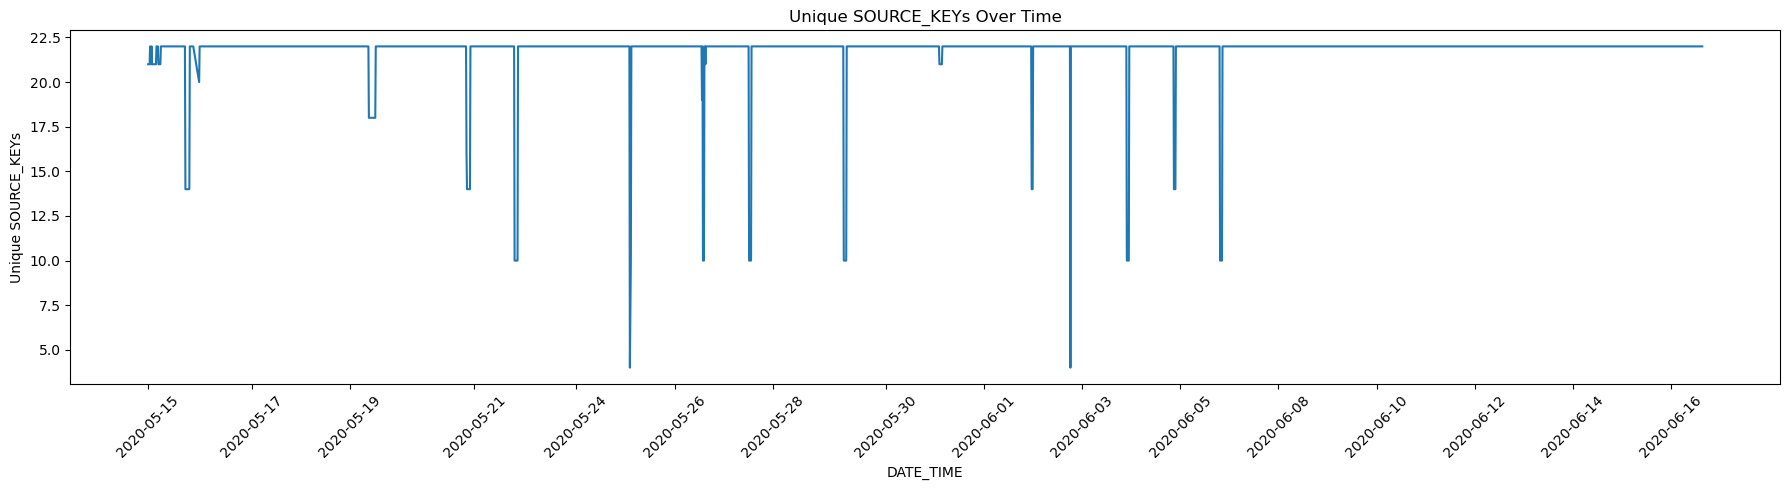

In [11]:
import matplotlib.pyplot as plt

# Ensure DATE_TIME is datetime
result['DATE_TIME'] = pd.to_datetime(result['DATE_TIME'])

plt.figure(figsize=(18,5))
plt.plot(result['DATE_TIME'], result['unique_SOURCE_KEYs'])

plt.xlabel("DATE_TIME")
plt.ylabel("Unique SOURCE_KEYs")
plt.title("Unique SOURCE_KEYs Over Time")

# Show only a few x-axis labels to avoid clutter
plt.xticks(result['DATE_TIME'][::200], rotation=45)

plt.tight_layout()
plt.show()


From the linechart we can see there is a variance of existence for unique timestamp numbers.
Now we will try to find the missing values

In [12]:
# Convert timestamps to datetime 
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'],dayfirst=True)
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'],dayfirst=True)

# Find timestamps that exist in weather but not in generation
missing_data = df_weather_sensor[~df_weather_sensor['DATE_TIME'].isin(df_power_generation['DATE_TIME'])]
print(f"Missing timestamp : ", len(missing_data))

Missing timestamp :  25


In [13]:
missing_data

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
542,2020-05-20 23:00:00,4135001,HmiyD2TTLFNqkNe,23.830852,21.024118,0.000000
543,2020-05-20 23:15:00,4135001,HmiyD2TTLFNqkNe,23.701162,20.786399,0.000000
544,2020-05-20 23:30:00,4135001,HmiyD2TTLFNqkNe,23.589626,20.572882,0.000000
545,2020-05-20 23:45:00,4135001,HmiyD2TTLFNqkNe,23.569009,20.622103,0.000000
546,2020-05-21 00:00:00,4135001,HmiyD2TTLFNqkNe,23.497382,20.584137,0.000000
547,2020-05-21 00:15:00,4135001,HmiyD2TTLFNqkNe,23.228943,20.230347,0.000000
548,2020-05-21 00:30:00,4135001,HmiyD2TTLFNqkNe,23.204518,20.179942,0.000000
731,2020-05-23 05:15:00,4135001,HmiyD2TTLFNqkNe,21.900024,20.994995,0.000000
919,2020-05-25 05:45:00,4135001,HmiyD2TTLFNqkNe,22.930503,21.104395,0.001908
1274,2020-05-28 22:30:00,4135001,HmiyD2TTLFNqkNe,21.259225,20.277036,0.000000


From the missing data we can see a pattern here irradiation is either 0 or so small nearby 0.

Now we will plot a graph to determine the Ac power generation distribution between day and night from the power generation dataframe

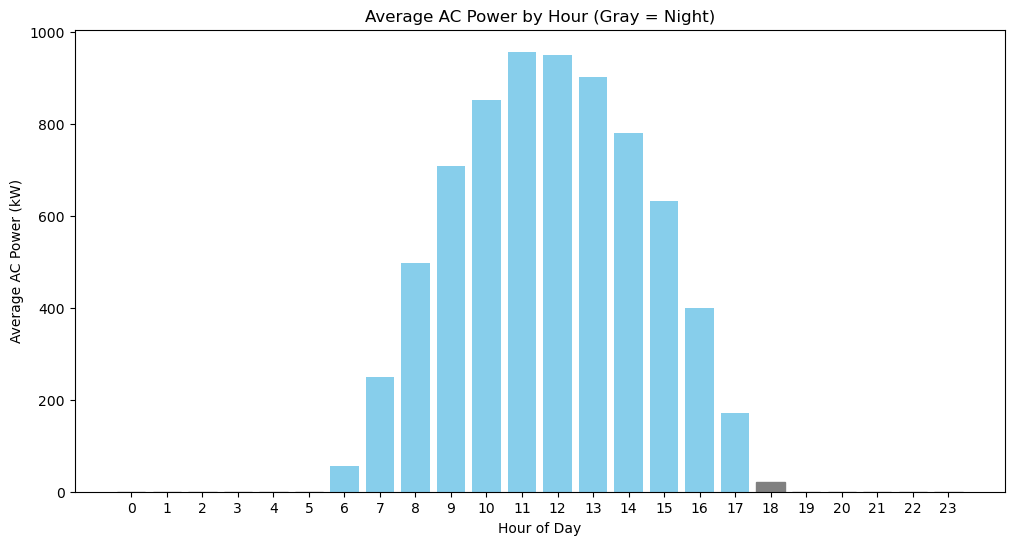

In [14]:
# Google colab help was taken in this part

import matplotlib.pyplot as plt
import pandas as pd

# Making sure DATE_TIME is datetime type
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'], dayfirst=True)

# Extract hour from timestamp
df_power_generation['hour'] = df_power_generation['DATE_TIME'].dt.hour

# Compute average AC power per hour (or sum if you prefer)
hourly_ac_power = df_power_generation.groupby('hour')['AC_POWER'].mean()

# Defining night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hourly_ac_power.index, hourly_ac_power.values, color='skyblue')

# Highlight night hours in gray
for bar, hour in zip(bars, hourly_ac_power.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power (kW)")
plt.title("Average AC Power by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


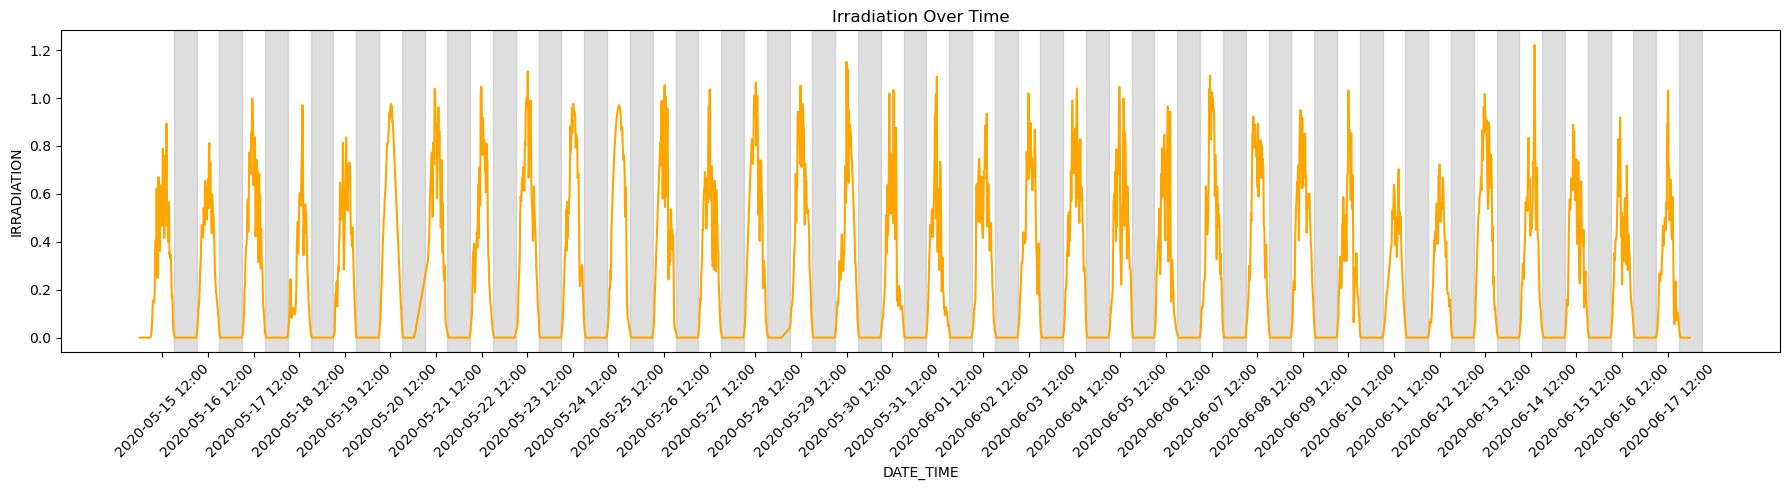

In [15]:
# Google colab help was taken to generate this graph

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure datetime
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'])
df_weather_sensor = df_weather_sensor.sort_values('DATE_TIME')

fig, ax = plt.subplots(figsize=(18,5))

# Plot irradiation line
ax.plot(df_weather_sensor['DATE_TIME'], df_weather_sensor['IRRADIATION'], color='orange')

# --- Shade night (6 PM → 6 AM next day) ---
for day in df_weather_sensor['DATE_TIME'].dt.date.unique():
    night_start = pd.Timestamp(f"{day} 18:00:00")
    night_end   = night_start + pd.Timedelta(hours=12)
    ax.axvspan(night_start, night_end, alpha=0.25, color='gray')

# --- X-axis: one tick per day at 12:00 PM ---
daily_ticks = pd.date_range(start=df_weather_sensor['DATE_TIME'].min().date(),
                            end=df_weather_sensor['DATE_TIME'].max().date(),
                            freq='D') + pd.Timedelta(hours=12)

ax.set_xticks(daily_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.xlabel("DATE_TIME")
plt.ylabel("IRRADIATION")
plt.title("Irradiation Over Time")

plt.tight_layout()
plt.show()


In the graph of irradiation vs time for weather sensor data the gray area is night time where the irradiation is 0 mostly. 

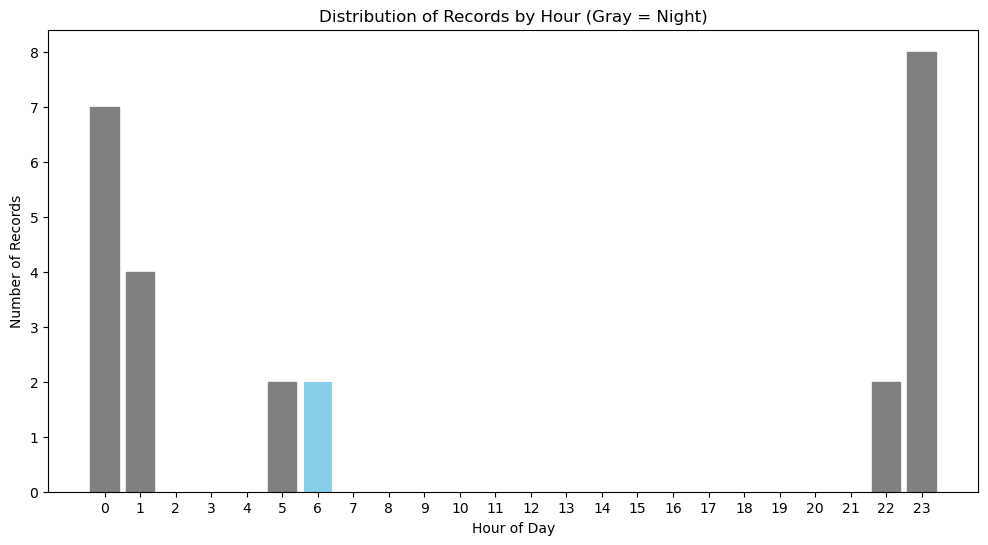

In [16]:
# Now we will plot a bar chart from the missing value to show the distribution of timestamp in either day or night

import matplotlib.pyplot as plt

# Extract hour from DATE_TIME
missing_data['hour'] = missing_data['DATE_TIME'].dt.hour

# Count records per hour
hour_counts = missing_data['hour'].value_counts().sort_index()

# Define night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hour_counts.index, hour_counts.values, color='skyblue')

# Highlight night hours
for bar, hour in zip(bars, hour_counts.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Records")
plt.title("Distribution of Records by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


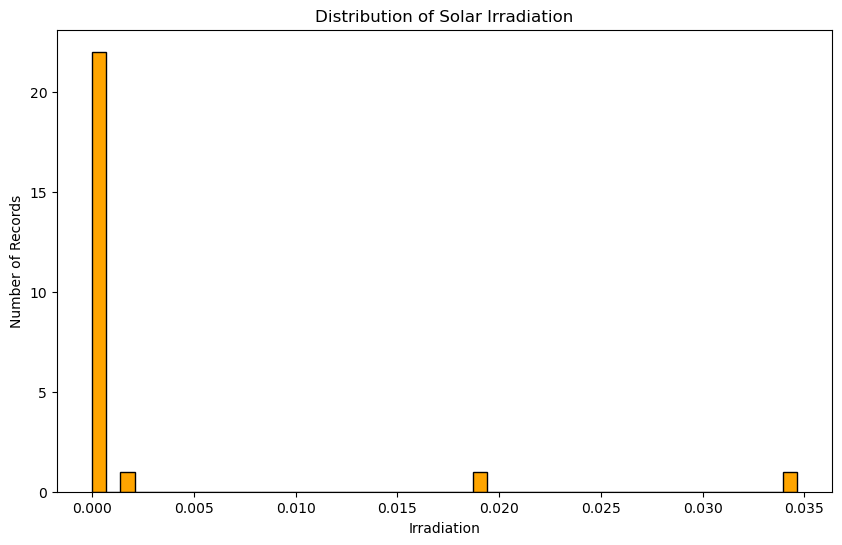

In [17]:
# This bar chart will show the irradiation distribution 

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(missing_data['IRRADIATION'], bins=50, color='orange', edgecolor='black')
plt.xlabel("Irradiation")
plt.ylabel("Number of Records")
plt.title("Distribution of Solar Irradiation")
plt.show()


The weather dataset has a fixed 15-minute interval. From the graph of irradiation vs temperature, we can say that irradiation is 0 at night time. For the missing value bar chart of the distribution of records by hour, it is clear that the missing value most of the time is associated with nighttime. And from the distribution of solar irradiation, it is also clear that most of the irradiation is 0. After finding the missing timestamps, we can say that they occur at night, with zero irradiation and no active inverters. From the AC Power generation distribution bar chart, we can see that the power generation is 0 when there is no irradiation. So it is safe to assume that power production is 0 for the missing values. 

## Steps for Handling Missing Values

For handling the missing values, here are the steps we will take

* We will group the generation data by timestamp and then sum the power from all inverters
* The weather data list of timestamps will be used to reindex the grouped result
* For a missing timestamp, the generated power will be filled with 0


This will ensure that the dataset is consistent and is ready to be merged, and zero values are explicitly represented


In [18]:
#Group by timestamp and sum across inverters
power_generation_grouped = df_power_generation.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].sum()

# Reindex to match the weather timestamps exactly which keeps missing timestamps and fills them with 0
power_generation_grouped = power_generation_grouped.reindex(df_weather_sensor['DATE_TIME']).fillna(0)

#Index reset to make DATE_TIME a column 
power_generation_grouped = power_generation_grouped.reset_index().rename(columns={'index': 'DATE_TIME'})

In [19]:
power_generation_grouped

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,0.0,0.0,0.000000,143581676.0
1,2020-05-15 00:15:00,0.0,0.0,0.000000,143581676.0
2,2020-05-15 00:30:00,0.0,0.0,0.000000,143581676.0
3,2020-05-15 00:45:00,0.0,0.0,0.000000,143581676.0
4,2020-05-15 01:00:00,0.0,0.0,0.000000,150761642.0
...,...,...,...,...,...
3177,2020-06-17 22:45:00,0.0,0.0,129571.000000,156142755.0
3178,2020-06-17 23:00:00,0.0,0.0,129571.000000,156142755.0
3179,2020-06-17 23:15:00,0.0,0.0,129571.000000,156142755.0
3180,2020-06-17 23:30:00,0.0,0.0,129571.000000,156142755.0


Now we will try to understand the structure of the power generation and weather sensor

In [20]:
#This will describe the power generation dataframe
df_power_generation.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,11.567216
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,6.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,12.000000
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,17.000000
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,23.000000
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,6.862477


We will set DATE_TIME as the index for both the weather and power-generation dataframes so that they become time-series datasets and can be accurately aligned, merged, and analyzed based on the same timestamps.

In [21]:
weather_df_set_index = df_weather_sensor.set_index('DATE_TIME')
generation_set_index = power_generation_grouped.set_index('DATE_TIME')

In [22]:
weather_df_set_index.describe()

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


In [23]:
generation_set_index.describe()

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,3182.000000,3182.000000,3182.000000,3.182000e+03
mean,68021.364537,6652.152733,71234.359461,1.508344e+08
std,87917.828216,8590.766175,66024.338720,1.694573e+07
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,10.982143,1.520026e+08
50%,7512.333333,726.013988,66060.455358,1.535195e+08
75%,139358.133927,13649.681696,129056.477679,1.549854e+08
max,298937.785710,29150.212499,193770.000000,1.561428e+08


In [24]:
# Checking length 
print (weather_df_set_index.info)
print (generation_set_index.info)

<bound method DataFrame.info of                      PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
DATE_TIME                                                             
2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
2020-05-15 01:00:00   4135001  HmiyD2TTLFNqkNe            24.621525   
...                       ...              ...                  ...   
2020-06-17 22:45:00   4135001  HmiyD2TTLFNqkNe            22.150570   
2020-06-17 23:00:00   4135001  HmiyD2TTLFNqkNe            22.129816   
2020-06-17 23:15:00   4135001  HmiyD2TTLFNqkNe            22.008275   
2020-06-17 23:30:00   4135001  HmiyD2TTLFNqkNe            21.969495   
2020-06-17 23:45:00   4135001  HmiyD2TTLFNqkNe            21.909288   

                     MODULE_TEMPERATURE  IRR

In [25]:
weather_df_set_index.index.equals(generation_set_index.index)

True

Now we will check if there is still any missing value

In [26]:
# Check for NaNs in weather data
print("Missing values in weather_df_set_index :")
print(weather_df_set_index.isna().sum())

# Check for NaNs in generation data
print("\nMissing values in generation_set_index:")
print(generation_set_index.isna().sum())

Missing values in weather_df_set_index :
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Missing values in generation_set_index:
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


There is no missing values for both of them also both of them has same length. So it is safe to merge data before EDA

# Merging Data And Feature Selection

Now our data cleaning and processing is done we can start for merging data. At first we will remove unnecessary columns

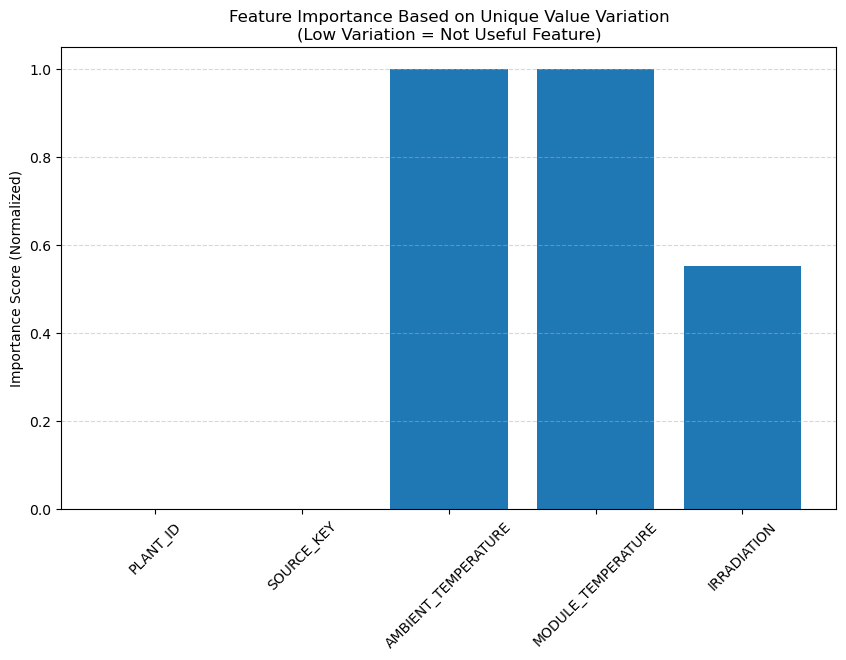

In [27]:
# Here we will show the feature importance and variation for weather_df_set_index 
# Calculate unique counts for each column (except the DATE_TIME index)
unique_counts = {
    "PLANT_ID": weather_df_set_index['PLANT_ID'].nunique(),
    "SOURCE_KEY": weather_df_set_index['SOURCE_KEY'].nunique(),
    "AMBIENT_TEMPERATURE": weather_df_set_index['AMBIENT_TEMPERATURE'].nunique(),
    "MODULE_TEMPERATURE": weather_df_set_index['MODULE_TEMPERATURE'].nunique(),
    "IRRADIATION": weather_df_set_index['IRRADIATION'].nunique()
}

# Convert to DataFrame
importance_df = pd.DataFrame.from_dict(unique_counts, orient='index', columns=['unique_values'])

# Normalize values (to look like feature importance)
importance_df['importance_score'] = importance_df['unique_values'] / importance_df['unique_values'].max()

# Plot
plt.figure(figsize=(10,6))
plt.bar(importance_df.index, importance_df['importance_score'])
plt.title("Feature Importance Based on Unique Value Variation\n(Low Variation = Not Useful Feature)")
plt.ylabel("Importance Score (Normalized)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


From this chart we can say plant id and source key is not necessary feature for our dataset. So we can remove these

In [28]:
# Plant id and source key are not required in this context as they are unnecessary features
weather_df_set_index = weather_df_set_index.drop(['PLANT_ID', 'SOURCE_KEY'], axis=1)
weather_df_set_index.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,
2020-05-15 00:00:00,25.184316,22.857507,0.0
2020-05-15 00:15:00,25.084589,22.761668,0.0
2020-05-15 00:30:00,24.935753,22.592306,0.0
2020-05-15 00:45:00,24.846130,22.360852,0.0
2020-05-15 01:00:00,24.621525,22.165423,0.0


In [29]:
generation_set_index.describe()


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,3182.000000,3182.000000,3182.000000,3.182000e+03
mean,68021.364537,6652.152733,71234.359461,1.508344e+08
std,87917.828216,8590.766175,66024.338720,1.694573e+07
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,10.982143,1.520026e+08
50%,7512.333333,726.013988,66060.455358,1.535195e+08
75%,139358.133927,13649.681696,129056.477679,1.549854e+08
max,298937.785710,29150.212499,193770.000000,1.561428e+08


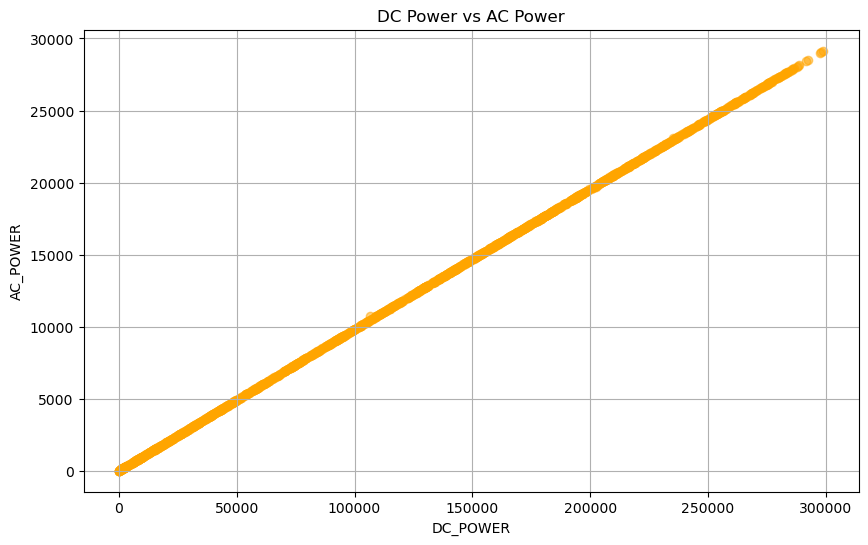

In [30]:
# Here we will find relation between DC power generation and AC power generation
# Filtering out zero DC_POWER to focus on daytime generation
daytime_generation = generation_set_index[generation_set_index['DC_POWER'] > 0]

plt.figure(figsize=(10,6))
plt.scatter(daytime_generation['DC_POWER'], daytime_generation['AC_POWER'], alpha=0.5, color='orange')
plt.title("DC Power vs AC Power")
plt.xlabel("DC_POWER")
plt.ylabel("AC_POWER")
plt.grid(True)
plt.show()


From the statistical properties, we can remove TOTAL_YIELD  because it shows a cumulative counter, unlike AC_POWER, which fluctuates. TOTAL_YIELD only increases from a  minimum 0 to a maximum of 1.56 * 10^8) but never decreases. This behavior means it carries no time-specific information about power generation.
Also, about DC_POWER we can remove it as we are predicting AC_POWER generation, and from this plot, it is clear that the relationship is linear, and there also DC_POWER is mostly a scaled value of AC_POWER, and it has no significant impact in this place

In [31]:
# Dropping dc power and total yield
generation_set_index = generation_set_index.drop(['DC_POWER', 'TOTAL_YIELD'], axis=1)
generation_set_index.head()

,AC_POWER,DAILY_YIELD
DATE_TIME,,
2020-05-15 00:00:00,0.0,0.0
2020-05-15 00:15:00,0.0,0.0
2020-05-15 00:30:00,0.0,0.0
2020-05-15 00:45:00,0.0,0.0
2020-05-15 01:00:00,0.0,0.0


Now based on timestamps of both dataset we can now safely merge

In [125]:
df = pd.merge(generation_set_index, weather_df_set_index, on='DATE_TIME')
df.head()

,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


In [126]:
# Saving the merged data into a csv file
df.to_csv('merged_data.csv', index=False)

For the answer of RQ7 Which features can be removed without harming performance, and which features are most useful for prediction (feature importance/selection)?
We can say from both datasets we can remove DC_POWER , TOTAL_YIELD , PLANT_ID, SOURCE_KEY without harming performance. The most useful feature is AMBIENT_TEMPERATURE, MODULE_TEMPERATURE and IRRADIATION

# Exploratory Data Analysis (EDA)

## The Goal

Before we take a decision and define which model shall we use, we need to do some data analysis, we need to understand the relationship between the features. After that we can make a decision which model we will chose. Here we will try to find 
* How power generation varies over time
* Weather impact on power generation
* The correlations among the features

## Approach

As we will predict power, at first we will find out the distributions of AC power, irradiation, module temperature and ambient temperature

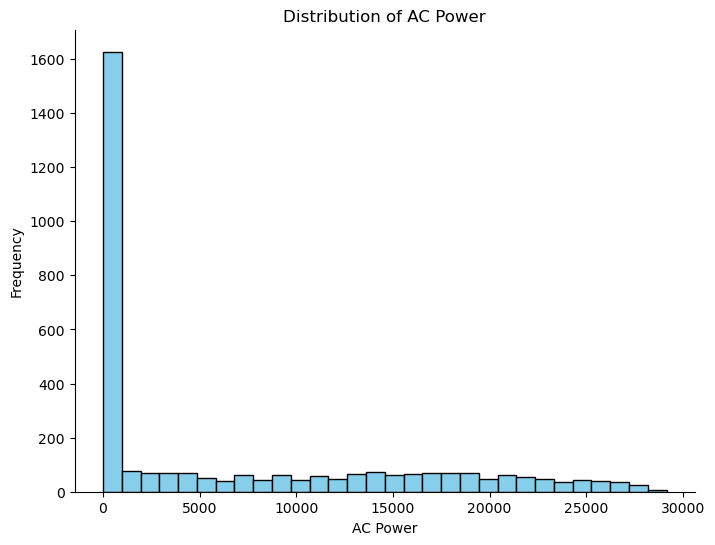

In [34]:
# Distribution of AC power
plt.figure(figsize=(8, 6))
plt.hist(df['AC_POWER'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of AC Power')
plt.xlabel('AC Power')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

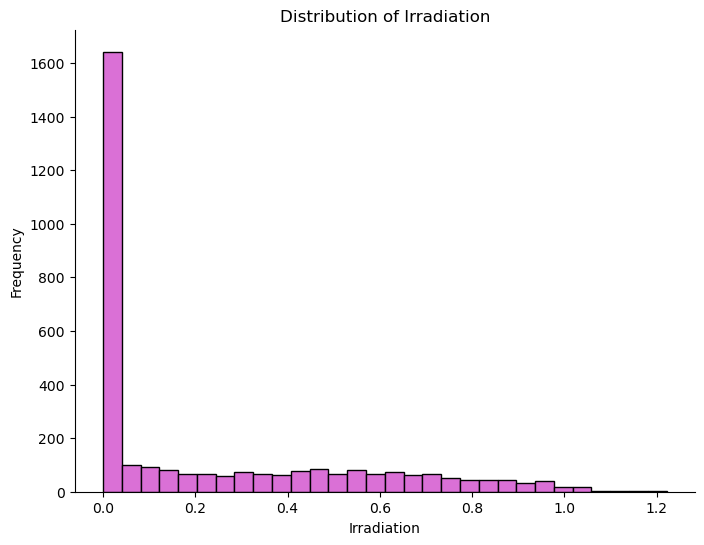

In [35]:
# Distribution of irradiation
plt.figure(figsize=(8, 6))
plt.hist(df['IRRADIATION'], bins=30, edgecolor='black', color='orchid')
plt.title('Distribution of Irradiation')
plt.xlabel('Irradiation')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

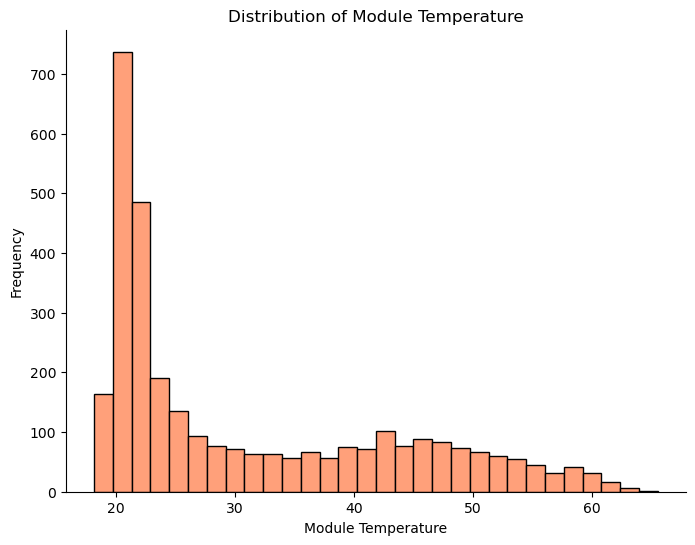

In [36]:
# Distribution of module temperature
plt.figure(figsize=(8, 6))
plt.hist(df['MODULE_TEMPERATURE'], bins=30, edgecolor='black', color='lightsalmon')
plt.title('Distribution of Module Temperature')
plt.xlabel('Module Temperature')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

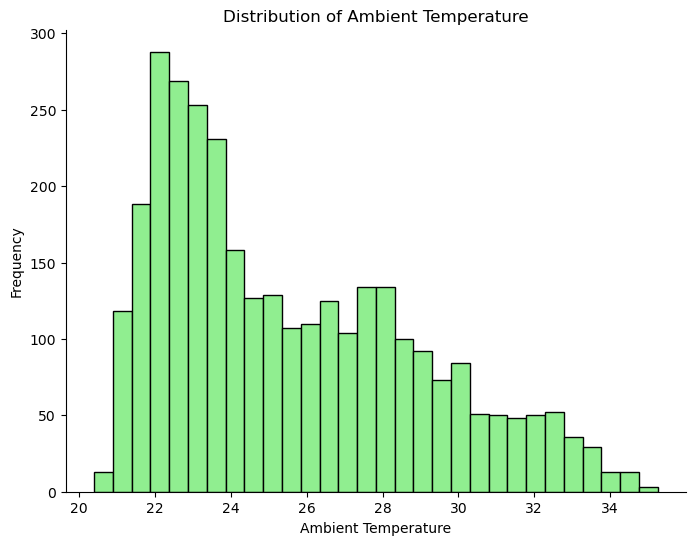

In [37]:
#Distribution of ambient temperature
plt.figure(figsize=(8, 6))
plt.hist(df['AMBIENT_TEMPERATURE'], bins=30, edgecolor='black', color='lightgreen')
plt.title('Distribution of Ambient Temperature')
plt.xlabel('Ambient Temperature')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

From the distributions, we can say Ac power and Irradiation shows almost identical distributions. The module temperature displays a strong right skew. The ambient temperature distribution is more symmetric, centered in the low- to mid-20s °C, reflecting normal outdoor conditions in a warm climate with natural daily fluctuations. AC power and irradiation distributions are dominated by a sharp spike at or near zero, which proves the variance between day and night.

## Feature Correlation heatmap

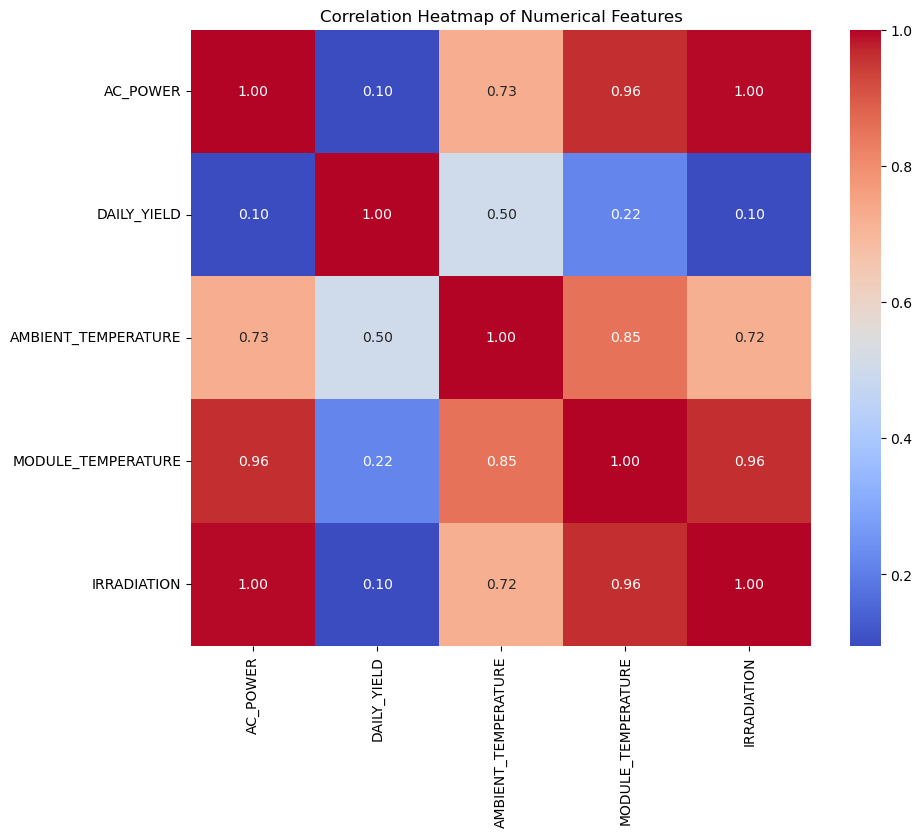

In [38]:
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title
plt.title('Correlation Heatmap of Numerical Features')

# Display the plot
plt.show()

If we see this heatmap it is clear that DAILY_YIELD has very least relation with AC_POWER which comes as 0.1, so it is safe to ignore this feature in the development of our model. On the other hand ambient temperature has 0.73 , module temperature has 0.96 and irradiation has 1 which is a very strong relation. Now we will do scatter plot for each one vs AC power

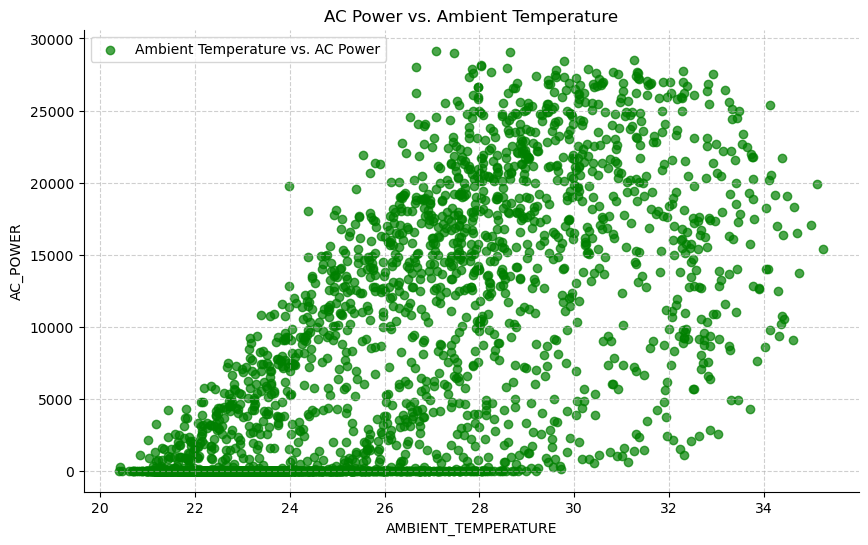

In [39]:
# AC power vs ambient temperature
plt.figure(figsize=(10, 6))
plt.scatter(df['AMBIENT_TEMPERATURE'], df['AC_POWER'], alpha=0.7, color='green', label='Ambient Temperature vs. AC Power')
plt.title('AC Power vs. Ambient Temperature')
plt.xlabel('AMBIENT_TEMPERATURE')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

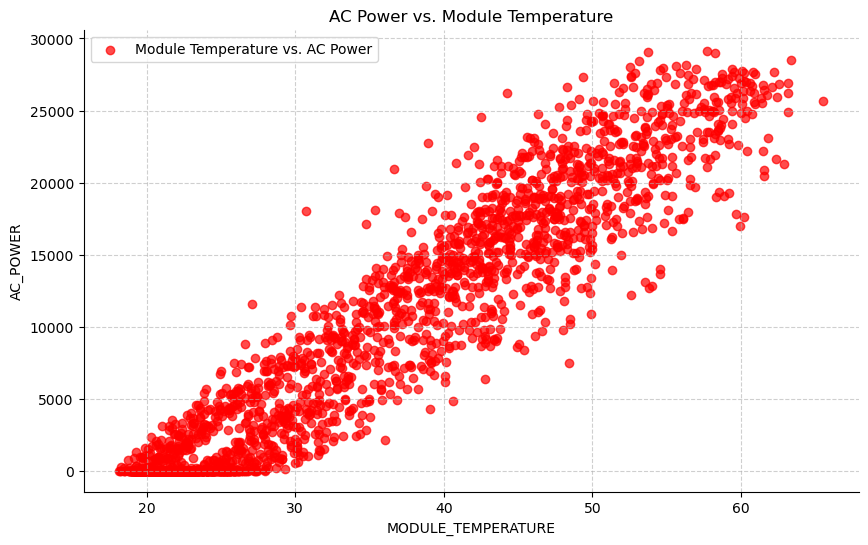

In [40]:
# AC power vs module temperature

plt.figure(figsize=(10, 6))
plt.scatter(df['MODULE_TEMPERATURE'], df['AC_POWER'], alpha=0.7, color='red', label='Module Temperature vs. AC Power')
plt.title('AC Power vs. Module Temperature')
plt.xlabel('MODULE_TEMPERATURE')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

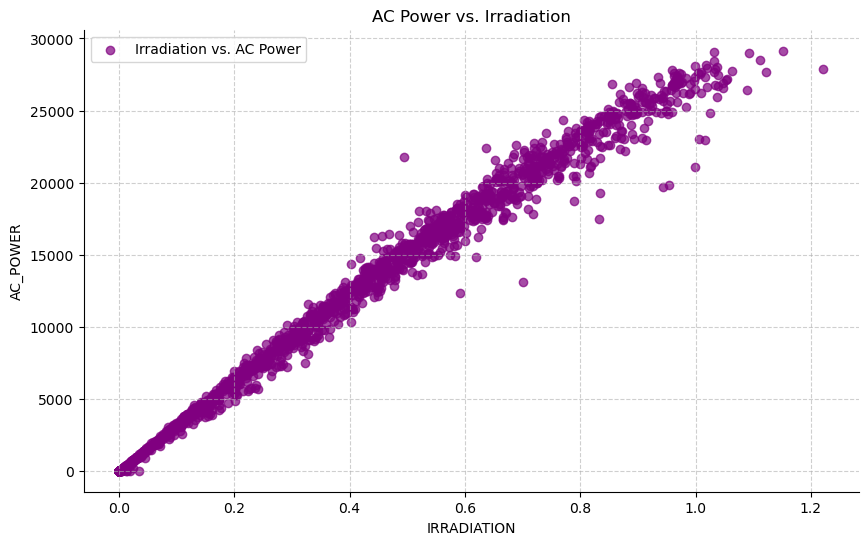

In [41]:
# AC power vs irradiation

plt.figure(figsize=(10, 6))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.7, color='purple', label='Irradiation vs. AC Power')
plt.title('AC Power vs. Irradiation')
plt.xlabel('IRRADIATION')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

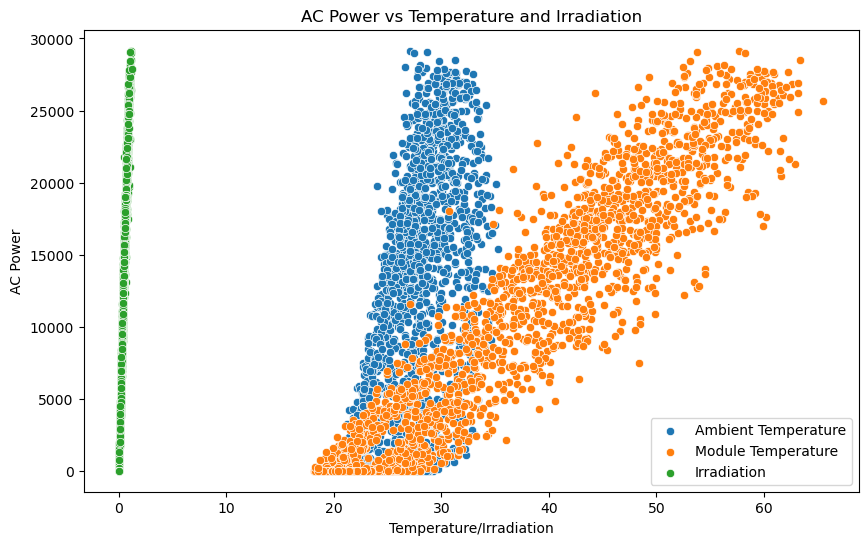

In [42]:
# Combined module temperature, irradiation , ambient temperature vs AC power

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='AMBIENT_TEMPERATURE', y='AC_POWER', label='Ambient Temperature', ax=ax)
sns.scatterplot(data=df, x='MODULE_TEMPERATURE', y='AC_POWER', label='Module Temperature', ax=ax)
sns.scatterplot(data=df, x='IRRADIATION', y='AC_POWER', label='Irradiation', ax=ax)

ax.set_xlabel('Temperature/Irradiation')
ax.set_ylabel('AC Power')
ax.set_title('AC Power vs Temperature and Irradiation')
ax.legend()
plt.show()

Now we will check AC power variance over time, which will help us what type of model we will choose for our machine learning part. 

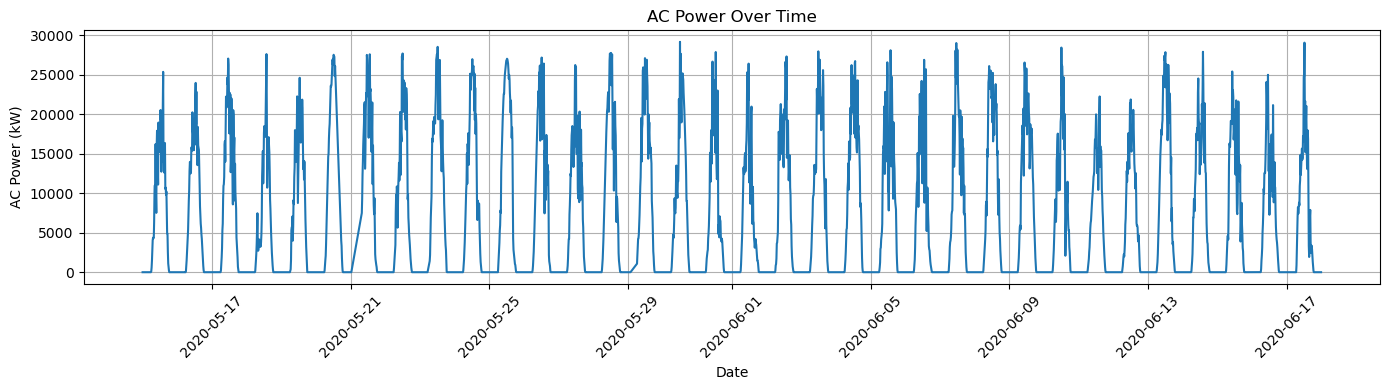

In [43]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['AC_POWER'])
plt.title('AC Power Over Time')
plt.xlabel('Date')
plt.ylabel('AC Power (kW)')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

We will plot a graph to show the irradiation and AC power generation relation. 

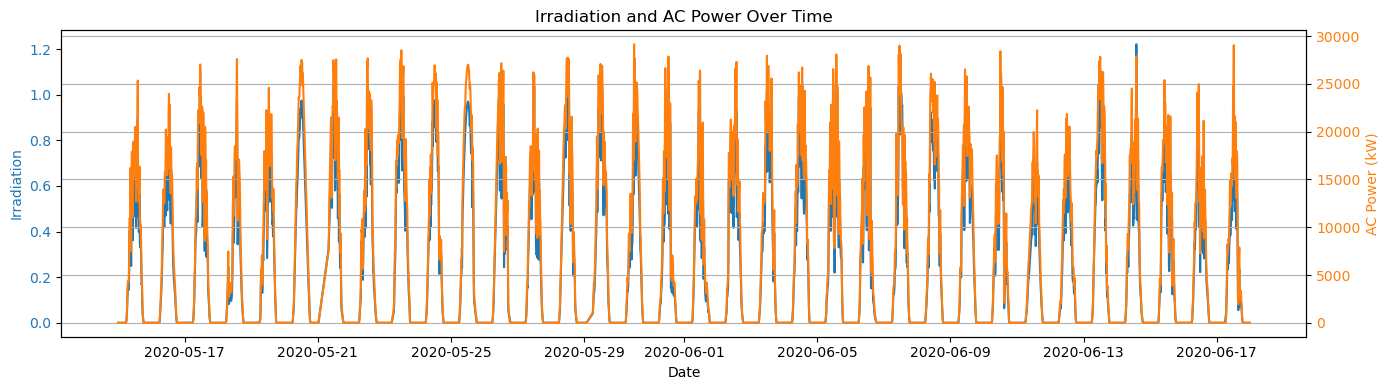

In [44]:
# Generative AI help was taken for this part
fig, ax1 = plt.subplots(figsize=(14, 4))

# Left axis for irradiation
ax1.plot(df.index, df['IRRADIATION'], color='tab:blue', label='Irradiation')
ax1.set_xlabel('Date')
ax1.set_ylabel('Irradiation', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis for AC Power
ax2 = ax1.twinx()
ax2.plot(df.index, df['AC_POWER'], color='tab:orange', label='AC Power')
ax2.set_ylabel('AC Power (kW)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title and layout
plt.title('Irradiation and AC Power Over Time')
fig.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



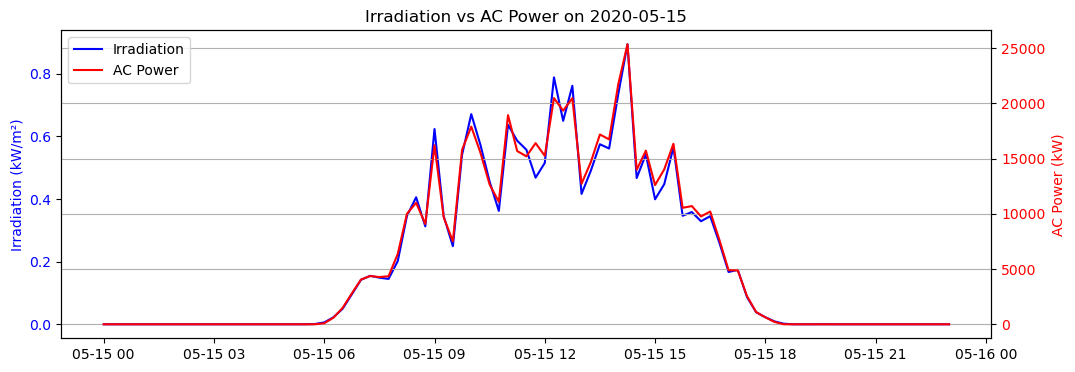

In [45]:
# Plotting based on different time
# Convert to datetime
# Ensure datetime conversion and extract date
# Select one day
sample_day = "2020-05-15"

# Filter one day using index
day_data = df.loc[sample_day]

fig, ax1 = plt.subplots(figsize=(12, 4))

# Irradiation (Blue)
ax1.plot(
    day_data.index, 
    day_data['IRRADIATION'], 
    color='blue', 
    label='Irradiation'
)
ax1.set_ylabel("Irradiation (kW/m²)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# AC Power (Red)
ax2 = ax1.twinx()
ax2.plot(
    day_data.index, 
    day_data['AC_POWER'], 
    color='red', 
    label='AC Power'
)
ax2.set_ylabel("AC Power (kW)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title + legends
plt.title(f"Irradiation vs AC Power on {sample_day}")

# Add legends for both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.grid(True)
plt.show()



From the graphical analysis we are clear about some point.
 * Here AC power generation is following time series where the rate fluctuates in different time
 * Ambient temperature, module temperature and irradiation has strong correlation with AC power generation
 * Irradiation has almost linear relation with AC power generation. As irradiation indicates sunlight so it is obvious power generation   will be affected in a proportion
 * The relation between ambient and module temperature is not following any linear relation hence it has a proportional relation with AC power generation 

# Model Selection

From the scatter plot it is clear that it is time series data also the relation is not linear. As we have to consider 3 features for non linear relations, these are the models suits better 
* Random Forest Regressor
* Xgboost Regressor
* HistGradientBoosting Regressor
* Feed-forward Neural Network

For our work in here, we will use 3 models (Random Forest, Xgboost, and Feed-forward neural network) and compare their performance. Also as a part of innovation, we will develop a neural network and evaluate its performance.

### Random Forest

<!-Need to paraphrase->

A random forest is a meta estimator that fits a number of decision tree regressors on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. During training, the tree builder makes decisions about where to direct samples with missing values relative to split points based on gain. It works by creating multiple decision trees, each trained on a random subset of the data. The process begins with Bootstrap sampling, where random rows of data are selected with replacement to form different training datasets for each tree. After this, we do feature sampling where only a random subset of features is used to build each tree, ensuring diversity in the models.

### Xgboost

<!-Need to paraphrase->

Traditional machine learning models like decision trees and random forests are easy to interpret but often struggle with accuracy on complex datasets. XGBoost short form for eXtreme Gradient Boosting is an advanced machine learning algorithm designed for efficiency, speed and high performance. It builds decision trees sequentially with each tree attempting to correct the mistakes made by the previous one. The process can be broken down as follows:

* Start with a base learner: The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.
* Calculate the errors: After training the first tree the errors between the predicted and actual values are calculated.
* Train the next tree: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.
* Repeat the process: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.
* Combine the predictions: The final prediction is the sum of the predictions from all the trees.


### Feedforward Neural Network

<!-Need to paraphrase->

Feedforward Neural Networks have a structured layered design where data flows sequentially through each layer.

* Input Layer: The input layer consists of neurons that receive the input data. Each neuron in the input layer represents a feature of the input data.
* Hidden Layers: One or more hidden layers are placed between the input and output layers. These layers are responsible for learning the complex patterns in the data. Each neuron in a hidden layer applies a weighted sum of inputs followed by a non-linear activation function.
* Output Layer: The output layer provides the final output of the network. The number of neurons in this layer corresponds to the number of classes in a classification problem or the number of outputs in a regression problem.

### Hyperparameter Finetuning

Hyper parameter tuning is a concept where in order to get high score from a model and good prediction capability from a model we will tune or change the values of the hyper parameters. Like for example when we are calling a model from sklearn library there are a bunch of parameters that we need to pass before training the model. The parameters that we will use we can either use grid search cv, manual search or using optuna. 
For our condition we will use optuna in all of our model hyper parameter tuning. 


### Why Optuna is better ?  

| Method          | Pros                                                                 | Cons                                                           | Trials Needed |
|-----------------|----------------------------------------------------------------------|----------------------------------------------------------------|---------------|
| Grid Search     |  Exhaustive search guarantees finding the best combination in the grid<br> Easy to implement |  Very slow for large parameter spaces<br> Does not scale well<br> Can be wasteful on unimportant parameters | High          |
| Random Search   |  Faster than Grid Search<br> Can explore a wider parameter space<br> Easy to implement |  May miss the global optimum<br> Results can vary due to randomness | Medium        |
| Optuna    |  Efficient Bayesian optimization<br> Adaptive search focuses on promising regions<br> Fewer trials needed for good results |  Slightly more complex setup<br> May require tuning of TPE parameters | Low           |


### Dataset Test Train Split

For our dataset we can't split test and train dataset randomly or shuffle randomly. We have to split based on time. Otherwise it will not give a good output based on different timestamp. 
From the prebuilt function that we have made earlier and put in util function we will do train test split based on date and time. As the data is time series so we can't randomly shuffle and split. We have to split based on our timeline. 
What we have to do is based on unique timestamps we will shuffle the datasets. The code is mentioned below. 

In [128]:
# Reset Index
df = df.reset_index()

# Convert the date_time column to datetime format
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Add a date column
df['DATE'] = df['DATE_TIME'].dt.date

df.head()

,DATE_TIME,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE
0,2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0,2020-05-15
1,2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0,2020-05-15
2,2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0,2020-05-15
3,2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0,2020-05-15
4,2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0,2020-05-15


In [47]:
# Getting the unique dates based on duplicate
unique_dates = df['DATE'].drop_duplicates().values
# 1. Shuffle the dates
np.random.seed(42)
np.random.shuffle(unique_dates)

# 2. Split the dates into train/test sets
split_ratio = 0.8
split_index = int(len(unique_dates) * split_ratio)
train_dates = unique_dates[:split_index]
test_dates  = unique_dates[split_index:]

# 3. Use those dates to select rows from df
train_df = df[df['DATE'].isin(train_dates)]
test_df  = df[df['DATE'].isin(test_dates)]

# Select features and target

features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
target = 'AC_POWER'

# Initialize scalers
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Fit only on training data
X_train = X_scaler.fit_transform(train_df[features])
y_train = y_scaler.fit_transform(train_df[[target]])

# Transform the test data
X_test = X_scaler.transform(test_df[features])
y_test = y_scaler.transform(test_df[[target]])


Now using this split theory and GroupKFold library we will create a function that will do the dataset split. Instead of using random seed we will use group k fold

In [48]:
# Convert date to group
df['GROUP'] = df['DATE'].astype(str)

# Prepare features and target
X = df[features].values
y = df['AC_POWER'].values.reshape(-1,1)
groups = df['GROUP']

# Initialize Group K-Fold
gkf = GroupKFold(n_splits=5)

# Loop through folds
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train_raw, y_test_raw = y[train_idx], y[test_idx]

    # Scale features and target
    X_scaler, y_scaler = MinMaxScaler(), MinMaxScaler()
    X_train = X_scaler.fit_transform(X_train_raw)
    X_test  = X_scaler.transform(X_test_raw)
    y_train = y_scaler.fit_transform(y_train_raw)
    y_test  = y_scaler.transform(y_test_raw)

    # Return fold info (dictionary)
    fold_data = {
        "fold": fold,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "X_scaler": X_scaler, "y_scaler": y_scaler
    }


For our future usage we will make it like a function and putting the function group_kfold_split_by_date under Util for future usage

### We will start with random forest at first

Now we will try to fine the best hyper parameters by finetuning using optuna beysian method

#### Hyper Parameter Tuning

For different dataset we used GroupKfold shuffle to create, train and test the model. From the test we have found the best R square which we will consider as the best dataset. Now using this dataset we will do optuna beysian hyper parameter tuning

In this part we will do a bunch of things. For hyper parameter tuning we will pass the required parameters, and find the best combination using optuna beysian hyper parameter tuning method. Also for the group k fold split we will split the dataset and will iterate in a loop. After that we will save the results in a csv file for future usage. Based on highest R square we will save the train test dataset.

## Main Code for Random Forest

In [49]:
# Global variables to track the best dataset across all trials
best_overall_r2 = -np.inf
best_overall_train_df = None
best_overall_test_df = None

def objective(trial, metrics_csv="fold_metrics_random_forest.csv", dataset_csv="best_dataset_random_forest.csv"):
    global best_overall_r2, best_overall_train_df, best_overall_test_df

    # 1. Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 5, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    fold_metrics = []

    # 2. Group K-Fold CV
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]

        # 3. Build and fit model
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)

        # 4. Predict and inverse transform
        preds = model.predict(X_test).reshape(-1, 1)
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1, 1))

        # 5. Metrics
        r2 = r2_score(real_y, preds)
        mae = mean_absolute_error(real_y, preds)
        rmse = np.sqrt(mean_squared_error(real_y, preds))

        fold_metrics.append({
            "fold": fold_data["fold"],
            "r2": r2,
            "mae": mae,
            "rmse": rmse
        })

        # Track the best fold across all trials
        if r2 > best_overall_r2:
            best_overall_r2 = r2
            best_overall_train_df = fold_data["train_df"]
            best_overall_test_df  = fold_data["test_df"]

    # 6. Save fold metrics for this trial
    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df["trial_number"] = trial.number
    fold_metrics_df.to_csv(metrics_csv, mode='a', index=False,
                           header=not pd.io.common.file_exists(metrics_csv))

    # 7. Store mean metrics in trial attributes
    mean_r2 = np.mean([m["r2"] for m in fold_metrics])
    trial.set_user_attr("mean_mae", np.mean([m["mae"] for m in fold_metrics]))
    trial.set_user_attr("mean_rmse", np.mean([m["rmse"] for m in fold_metrics]))

    return mean_r2


In [50]:
# Create study → Bayesian optimization
study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler()
)

# Run optimization
study_rf.optimize(objective, n_trials=50, show_progress_bar=True)

# Best trial
best_trial = study_rf.best_trial

print("Best Trial Results")
print("Mean R² Score across folds:", best_trial.value)
print("Mean MAE across folds :", best_trial.user_attrs["mean_mae"])
print("Mean RMSE across folds:", best_trial.user_attrs["mean_rmse"])

print("\nBest Hyperparameters:")
for k, v in best_trial.params.items():
    print(f"  {k}: {v}")

# Save the global best dataset after all trials
if best_overall_train_df is not None and best_overall_test_df is not None:
    best_overall_train_df.to_csv("best_train_dataset_random_forest.csv", index=False)
    best_overall_test_df.to_csv("best_test_dataset_random_forest.csv", index=False)
    print("Best train/test datasets saved with highest R² score:", best_overall_r2)


print("\nBest train/test datasets with highest R² across all trials saved to CSV.")
best_train_path = "best_train_dataset_random_forest.csv"
best_test_path  = "best_test_dataset_random_forest.csv"
print("Train dataset:", best_train_path)
print("Test dataset :", best_test_path)

# Optional: load it to check shape
best_train_df = pd.read_csv(best_train_path)
best_test_df  = pd.read_csv(best_test_path)
print("Train shape:", best_train_df.shape)
print("Test shape :", best_test_df.shape)


[I 2025-12-01 08:32:03,846] A new study created in memory with name: no-name-58efa6a8-e92e-445f-844b-6c0ada39d03d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-01 08:32:08,564] Trial 0 finished with value: 0.9912952875160579 and parameters: {'n_estimators': 1163, 'max_depth': 43, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.5384727842318878, 'bootstrap': False}. Best is trial 0 with value: 0.9912952875160579.
[I 2025-12-01 08:32:14,372] Trial 1 finished with value: 0.9939745268523945 and parameters: {'n_estimators': 991, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.8276841001681137, 'bootstrap': True}. Best is trial 1 with value: 0.9939745268523945.
[I 2025-12-01 08:32:20,433] Trial 2 finished with value: 0.9920978296034739 and parameters: {'n_estimators': 1069, 'max_depth': 51, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.4789503222726976, 'bootstrap': False}. Best is trial 1 with value: 0.9939745268523945.
[I 2025-12-01 08:32:26,550] Trial 3 finished with value: 0.990907848970806 and parameters: {'n_estimators': 851, 'max_depth': 27, 'min_samples_split

In [51]:
# Get best hyperparameters from Optuna
best_params = best_trial.params
best_params["random_state"] = 30
best_params["n_jobs"] = -1

# Retrieve the best fold datasets for the trial
best_train_df = pd.read_csv('best_train_dataset_random_forest.csv')
best_test_df  = pd.read_csv('best_test_dataset_random_forest.csv')

# Separate features and target
X_train = best_train_df[features].values
y_train = best_train_df["AC_POWER"].values.ravel()

X_test  = best_test_df[features].values
y_test  = best_test_df["AC_POWER"].values.ravel()

# Fit the final Random Forest model
best_rf_model = RandomForestRegressor(**best_params)
best_rf_model.fit(X_train, y_train)

# Predict on test set
final_pred = best_rf_model.predict(X_test)

# Evaluate
final_r2 = r2_score(y_test, final_pred)
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("Final R²:", final_r2)
print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)


Final R²: 0.9965320435705403
Final MAE: 278.238692420076
Final RMSE: 529.836875121668


### Graphical Analysis

In [52]:
y_pred_rf = final_pred

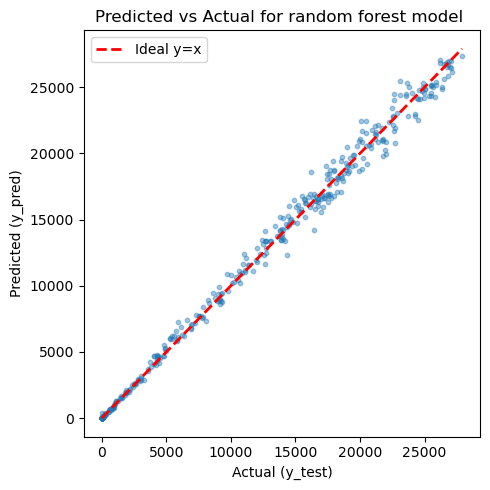

In [53]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_rf, s=10, alpha=0.4)
lo, hi = min(np.min(y_test), np.min(y_pred_rf)), max(np.max(y_test), np.max(y_pred_rf))
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal y=x')
plt.xlabel('Actual (y_test)'); plt.ylabel('Predicted (y_pred)')
plt.title('Predicted vs Actual for random forest model '); plt.legend(); plt.tight_layout();
plt.show()

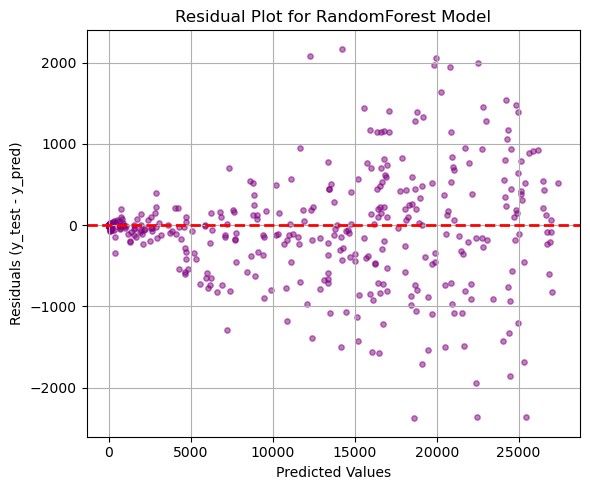

In [54]:
# Ensuring y_test and y_pred are both 1D arrays of same length
y_test_aligned = np.array(y_test).flatten()
y_pred_aligned = np.array(y_pred_rf).flatten()

# Compute residuals
residuals = y_test_aligned - y_pred_aligned

# Residual plot
plt.figure(figsize=(6,5))
plt.scatter(y_pred_aligned, residuals, alpha=0.5, s=15, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)  # horizontal line at 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residual Plot for RandomForest Model')
plt.grid(True)
plt.tight_layout()
plt.show()

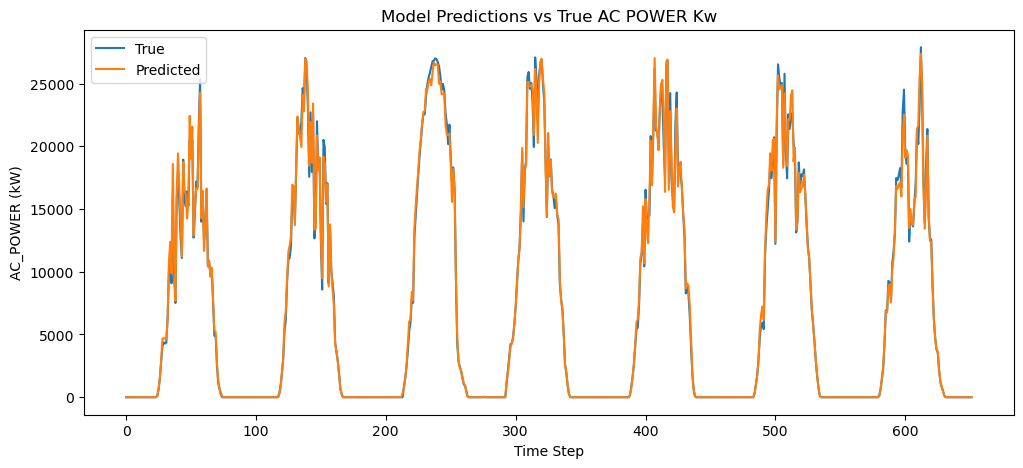

In [55]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='True')
plt.plot(y_pred_rf, label='Predicted')
plt.legend()
plt.title('Model Predictions vs True AC POWER Kw')
plt.xlabel('Time Step')
plt.ylabel('AC_POWER (kW)')
plt.show()

### Statistical Analysis For Random Forest

In [56]:
# 1. Load fold metrics CSV

metrics_csv = "fold_metrics_random_forest.csv"  # Change if needed
metrics_df = pd.read_csv(metrics_csv)

In [57]:
# Describe 
desc_stats = metrics_df[['r2','mae','rmse']].describe()
desc_stats

,r2,mae,rmse
count,500.000000,500.000000,500.000000
mean,0.993294,325.577636,674.297336
std,0.003250,47.959195,127.768924
min,0.984062,271.952500,528.559489
25%,0.992095,282.451171,547.144326
50%,0.994397,314.805769,670.300646
75%,0.996281,351.318196,764.825247
max,0.996549,490.102302,999.168558


In [58]:
# Fold-level performance analysis
fold_stats = metrics_df.groupby('fold')[['r2','mae','rmse']].agg(['mean','std','min','max'])
fold_stats

r2                                       mae             \
          mean       std       min       max        mean        std   
fold                                                                  
1     0.987909  0.001434  0.984062  0.988839  373.452700  41.341931   
2     0.992064  0.001481  0.987609  0.993016  338.436226  38.808231   
3     0.994801  0.000835  0.992224  0.995378  312.164478  31.144267   
4     0.995800  0.001171  0.992397  0.996549  308.843149  48.749592   
5     0.995895  0.000794  0.993113  0.996456  294.991628  33.762263   

                                    rmse                                     
             min         max        mean        std         min         max  
fold                                                                         
1     345.534776  490.102302  868.869697  49.777833  836.125490  999.168558  
2     313.551532  460.143995  733.745222  65.256561  691.008842  920.403126  
3     291.506959  404.551320  618.257129  47.463919  584.619806  758.263128  
4     277.135831  446.158300  578.176696  75.654080  528.559489  784.511604  
5     271.952500  403.678945  572.437936  52.688119  534.104253  744.524975

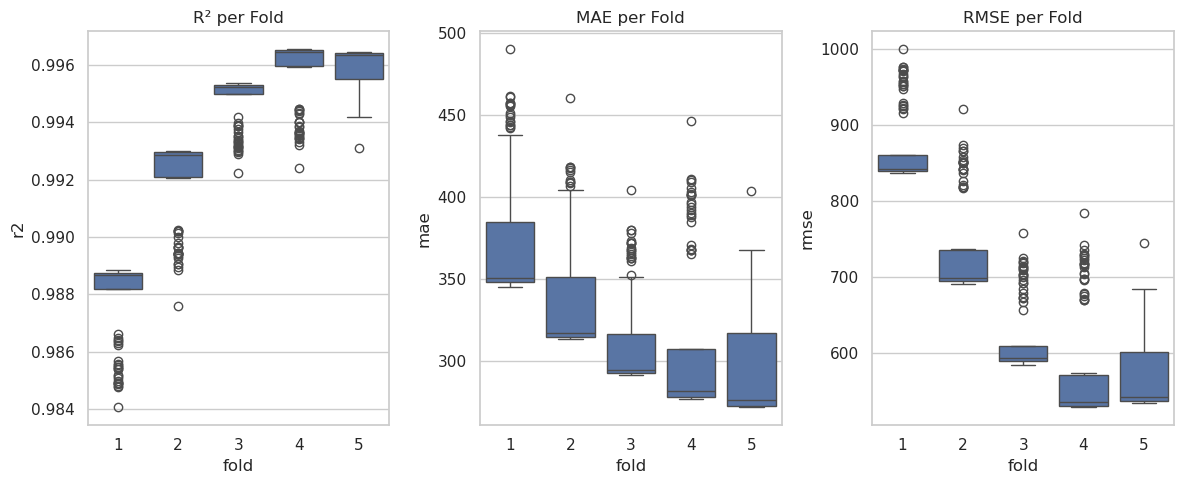

In [59]:
# Visualize
sns.set(style="whitegrid")

# Boxplots
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(x='fold', y='r2', data=metrics_df)
plt.title('R² per Fold')

plt.subplot(1,3,2)
sns.boxplot(x='fold', y='mae', data=metrics_df)
plt.title('MAE per Fold')

plt.subplot(1,3,3)
sns.boxplot(x='fold', y='rmse', data=metrics_df)
plt.title('RMSE per Fold')

plt.tight_layout()
plt.show()

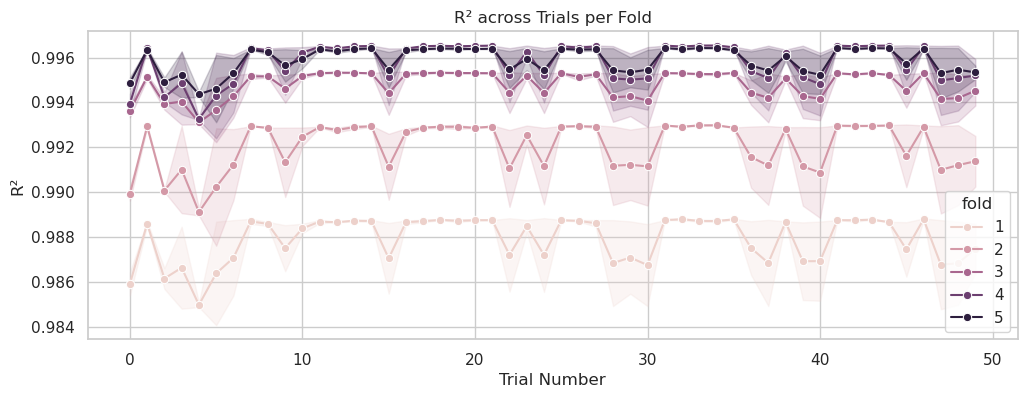

In [60]:
# Line plots: metric trend across trials
plt.figure(figsize=(12,4))
sns.lineplot(x='trial_number', y='r2', hue='fold', data=metrics_df, marker='o')
plt.title("R² across Trials per Fold")
plt.xlabel("Trial Number")
plt.ylabel("R²")
plt.show()

In [61]:
# Example: ANOVA to check if R² differs significantly between folds
fold_r2_groups = [metrics_df[metrics_df['fold']==f]['r2'] for f in metrics_df['fold'].unique()]
anova_result = f_oneway(*fold_r2_groups)
print("\nANOVA for R² across folds")
print(f"F-statistic: {anova_result.statistic:.4f}, p-value: {anova_result.pvalue:.4f}")

# Paired t-test example: fold 1 vs fold 2 R²
t_stat, p_val = ttest_rel(metrics_df[metrics_df['fold']==1]['r2'].values,
                          metrics_df[metrics_df['fold']==2]['r2'].values)
print("\nPaired t-test Fold 1 vs Fold 2 R²:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


ANOVA for R² across folds
F-statistic: 824.2635, p-value: 0.0000

Paired t-test Fold 1 vs Fold 2 R²:
t-statistic: -203.4044, p-value: 0.0000


In [62]:
# 7. Confidence intervals
def compute_ci(data, confidence=0.95):
    mean = np.mean(data)
    sem  = stats.sem(data)
    ci_lower, ci_upper = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    return mean, ci_lower, ci_upper

print("\n95% Confidence Intervals ")
for metric in ['r2','mae','rmse']:
    mean, ci_lower, ci_upper = compute_ci(metrics_df[metric])
    print(f"{metric}: Mean={mean:.4f}, 95% CI=({ci_lower:.4f}, {ci_upper:.4f})")


95% Confidence Intervals 
r2: Mean=0.9933, 95% CI=(0.9930, 0.9936)
mae: Mean=325.5776, 95% CI=(321.3637, 329.7916)
rmse: Mean=674.2973, 95% CI=(663.0709, 685.5238)


In [63]:
best_row = metrics_df.loc[metrics_df['r2'].idxmax()]
print("\n Best Trial/Fold")
print(best_row)
print(f"Trial {best_row['trial_number']} - Fold {best_row['fold']} has the highest R²: {best_row['r2']:.4f}")


 Best Trial/Fold
fold              4.000000
r2                0.996549
mae             277.285993
rmse            528.559489
trial_number     19.000000
Name: 348, dtype: float64
Trial 19.0 - Fold 4.0 has the highest R²: 0.9965


## XGBoost

## Main Code for XGBoost

In [64]:
# New method for objective xgb (hyper tune and add k fold in same code )
# Global variables to track the best dataset across all trials for XGBoost
best_overall_r2_xgb = -np.inf
best_overall_train_df_xgb = None
best_overall_test_df_xgb = None

def objective_xgb(trial, metrics_csv="fold_metrics_xgboost.csv"):
    global best_overall_r2_xgb, best_overall_train_df_xgb, best_overall_test_df_xgb

    # 1. Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "random_state": 30,
        "n_jobs": -1
    }

    fold_metrics = []

    # 2. Group K-Fold CV
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]

        # 3. Build and fit XGBoost model
        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        # 4. Predict and inverse transform
        preds = model.predict(X_test).reshape(-1, 1)
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1, 1))

        # 5. Metrics
        r2 = r2_score(real_y, preds)
        mae = mean_absolute_error(real_y, preds)
        rmse = np.sqrt(mean_squared_error(real_y, preds))

        fold_metrics.append({
            "fold": fold_data["fold"],
            "r2": r2,
            "mae": mae,
            "rmse": rmse
        })

        # Track the best fold across all trials
        if r2 > best_overall_r2_xgb:
            best_overall_r2_xgb = r2
            best_overall_train_df_xgb = fold_data["train_df"]
            best_overall_test_df_xgb  = fold_data["test_df"]

    # 6. Save fold metrics for this trial
    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df["trial_number"] = trial.number
    fold_metrics_df.to_csv(metrics_csv, mode='a', index=False,
                           header=not pd.io.common.file_exists(metrics_csv))

    # 7. Store mean metrics in trial attributes
    mean_r2 = np.mean([m["r2"] for m in fold_metrics])
    trial.set_user_attr("mean_mae", np.mean([m["mae"] for m in fold_metrics]))
    trial.set_user_attr("mean_rmse", np.mean([m["rmse"] for m in fold_metrics]))

    return mean_r2

In [65]:
# Create study → Bayesian optimization for XGBoost
study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler()
)

# Run optimization
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

# Best trial
best_trial_xgb = study_xgb.best_trial

print("Best Trial Results (XGBoost)")
print("Mean R² Score across folds:", best_trial_xgb.value)
print("Mean MAE across folds :", best_trial_xgb.user_attrs["mean_mae"])
print("Mean RMSE across folds:", best_trial_xgb.user_attrs["mean_rmse"])

print("\nBest Hyperparameters:")
for k, v in best_trial_xgb.params.items():
    print(f"  {k}: {v}")

# Save the global best dataset after all trials
if best_overall_train_df_xgb is not None and best_overall_test_df_xgb is not None:
    best_overall_train_df_xgb.to_csv("best_train_dataset_xgboost.csv", index=False)
    best_overall_test_df_xgb.to_csv("best_test_dataset_xgboost.csv", index=False)
    print("Best train/test datasets saved with highest R² score:", best_overall_r2_xgb)

print("\nBest train/test datasets with highest R² across all trials saved to CSV.")
best_train_path = "best_train_dataset_xgboost.csv"
best_test_path  = "best_test_dataset_xgboost.csv"
print("Train dataset:", best_train_path)
print("Test dataset :", best_test_path)

# Optional: load it to check shape
best_train_df_xgb = pd.read_csv(best_train_path)
best_test_df_xgb  = pd.read_csv(best_test_path)
print("Train shape:", best_train_df_xgb.shape)
print("Test shape :", best_test_df_xgb.shape)


[I 2025-12-01 08:37:28,269] A new study created in memory with name: no-name-66d54832-080d-4e38-b21d-450ef713ea55


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-01 08:37:29,010] Trial 0 finished with value: 0.9547880205007828 and parameters: {'n_estimators': 740, 'max_depth': 4, 'learning_rate': 0.2709496145248789, 'subsample': 0.5295031122597402, 'colsample_bytree': 0.6923081587339387, 'gamma': 3.550640701370995, 'reg_alpha': 0.340231820473924, 'reg_lambda': 0.5939944911939294}. Best is trial 0 with value: 0.9547880205007828.
[I 2025-12-01 08:37:29,461] Trial 1 finished with value: 0.9909920868729453 and parameters: {'n_estimators': 415, 'max_depth': 3, 'learning_rate': 0.05740427285703561, 'subsample': 0.8426168073058447, 'colsample_bytree': 0.6993442283172564, 'gamma': 0.1168206582911796, 'reg_alpha': 0.4639887972609461, 'reg_lambda': 0.18668313017906457}. Best is trial 1 with value: 0.9909920868729453.
[I 2025-12-01 08:37:29,910] Trial 2 finished with value: 0.9708556515288198 and parameters: {'n_estimators': 391, 'max_depth': 7, 'learning_rate': 0.2179543817095498, 'subsample': 0.7563406085498019, 'colsample_bytree': 0.66778303

In [66]:
# Get best hyperparameters from Optuna for XGBoost
best_params = best_trial_xgb.params.copy()
best_params["random_state"] = 30
best_params["n_jobs"] = -1
best_params["objective"] = "reg:squarederror"  # required for regression

# Retrieve the best fold datasets for the trial
best_train_df = pd.read_csv('best_train_dataset_xgboost.csv')
best_test_df  = pd.read_csv('best_test_dataset_xgboost.csv')

# Separate features and target
X_train = best_train_df[features].values
y_train = best_train_df["AC_POWER"].values.ravel()

X_test  = best_test_df[features].values
y_test  = best_test_df["AC_POWER"].values.ravel()

# Fit the final XGBoost model
best_xgb_model = xgb.XGBRegressor(**best_params)
best_xgb_model.fit(X_train, y_train)

# Predict on test set
final_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate
final_r2 = r2_score(y_test, final_pred_xgb)
final_mae = mean_absolute_error(y_test, final_pred_xgb)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred_xgb))
y_pred_xgb = final_pred_xgb

print("Final R²:", final_r2)
print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)

Final R²: 0.9953509134228942
Final MAE: 317.39917583251975
Final RMSE: 611.7232199541965


### Graphical Analysis

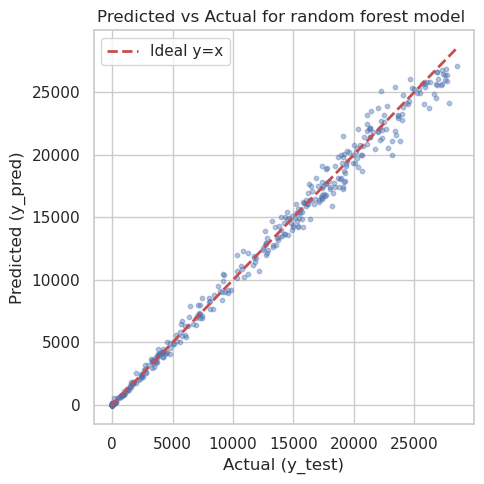

In [67]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_xgb, s=10, alpha=0.4)
lo, hi = min(np.min(y_test), np.min(y_pred_xgb)), max(np.max(y_test), np.max(y_pred_xgb))
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal y=x')
plt.xlabel('Actual (y_test)'); plt.ylabel('Predicted (y_pred)')
plt.title('Predicted vs Actual for random forest model '); plt.legend(); plt.tight_layout();
plt.show()

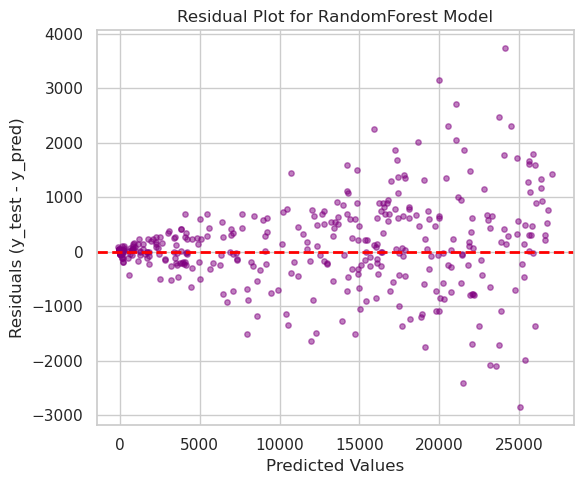

In [68]:
# Ensuring y_test and y_pred are both 1D arrays of same length
y_test_aligned = np.array(y_test).flatten()
y_pred_aligned = np.array(y_pred_xgb).flatten()

# Compute residuals
residuals = y_test_aligned - y_pred_aligned

# Residual plot
plt.figure(figsize=(6,5))
plt.scatter(y_pred_aligned, residuals, alpha=0.5, s=15, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)  # horizontal line at 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residual Plot for RandomForest Model')
plt.grid(True)
plt.tight_layout()
plt.show()

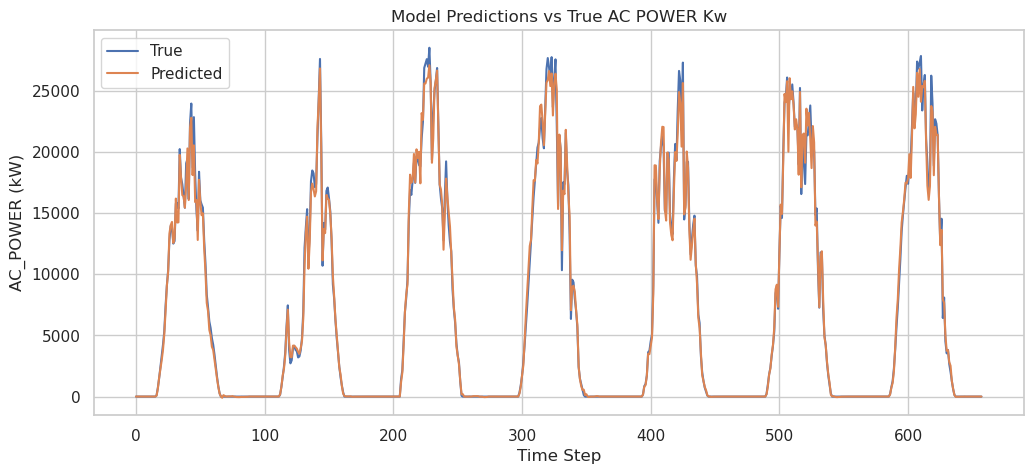

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='True')
plt.plot(y_pred_xgb, label='Predicted')
plt.legend()
plt.title('Model Predictions vs True AC POWER Kw')
plt.xlabel('Time Step')
plt.ylabel('AC_POWER (kW)')
plt.show()

Learning Rate Curve

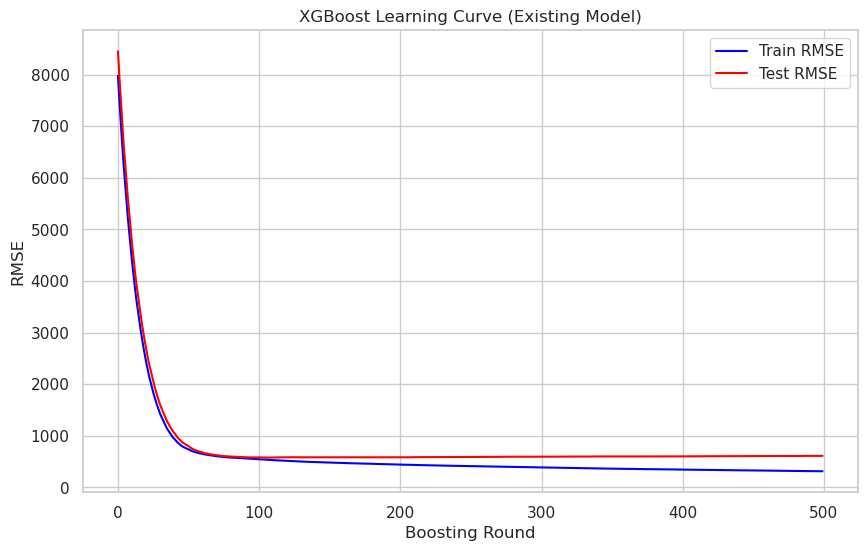

In [70]:
# Create DMatrices
dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

# Get booster
booster = best_xgb_model.get_booster()

# Use the number of trees from the model's n_estimators
n_trees = best_xgb_model.n_estimators

# Calculate train/test RMSE per iteration
train_rmse = []
test_rmse  = []

for i in range(n_trees):
    train_pred = booster.predict(dtrain, iteration_range=(0, i+1))
    test_pred  = booster.predict(dtest, iteration_range=(0, i+1))
    
    train_rmse.append(np.sqrt(np.mean((y_train - train_pred)**2)))
    test_rmse.append(np.sqrt(np.mean((y_test - test_pred)**2)))

# Plot
plt.figure(figsize=(10,6))
plt.plot(train_rmse, label='Train RMSE', color='blue')
plt.plot(test_rmse, label='Test RMSE', color='red')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve (Existing Model)')
plt.legend()
plt.grid(True)
plt.show()

The groupkfold split function that we wrote we can also use that function in here. 

### Statistical Analysis For XGBoost

In [71]:
# 1. Load fold metrics CSV

metrics_csv = "fold_metrics_xgboost.csv"  # Change if needed
metrics_df_xgboost = pd.read_csv(metrics_csv)

In [72]:
# Describe 
desc_stats_xgboost = metrics_df_xgboost[['r2','mae','rmse']].describe()
desc_stats_xgboost

,r2,mae,rmse
count,500.000000,500.000000,500.000000
mean,0.976381,881.483346,1228.676063
std,0.017649,372.170910,453.207831
min,0.911756,337.136128,580.607506
25%,0.969870,585.312553,893.044388
50%,0.982957,800.582002,1098.312786
75%,0.989264,1116.787774,1491.791096
max,0.995812,1947.331861,2512.072699


In [73]:
fold_stats_xgboost = metrics_df_xgboost.groupby('fold')[['r2','mae','rmse']].agg(['mean','std','min','max'])
fold_stats_xgboost

r2                                       mae              \
          mean       std       min       max        mean         std   
fold                                                                   
1     0.971785  0.018575  0.911756  0.986843  889.102119  335.351833   
2     0.976329  0.015562  0.928372  0.991686  863.843588  336.733717   
3     0.976900  0.018233  0.921906  0.994770  881.225845  391.187329   
4     0.979886  0.016982  0.925310  0.995691  863.446261  393.457357   
5     0.977004  0.018098  0.921599  0.995812  909.798915  403.675838   

                                      rmse                          \
             min          max         mean         std         min   
fold                                                                 
1     429.947391  1769.278842  1273.639851  383.023056  907.837999   
2     385.152804  1725.713046  1214.100717  381.843226  753.963435   
3     348.457654  1866.208648  1215.730702  482.172022  621.891904   
4     341.620842  1894.237782  1176.146951  497.377805  590.632168   
5     337.136128  1947.331861  1263.762093  506.402462  580.607506   

                   
              max  
fold               
1     2351.094097  
2     2212.966584  
3     2403.059361  
4     2458.880429  
5     2512.072699

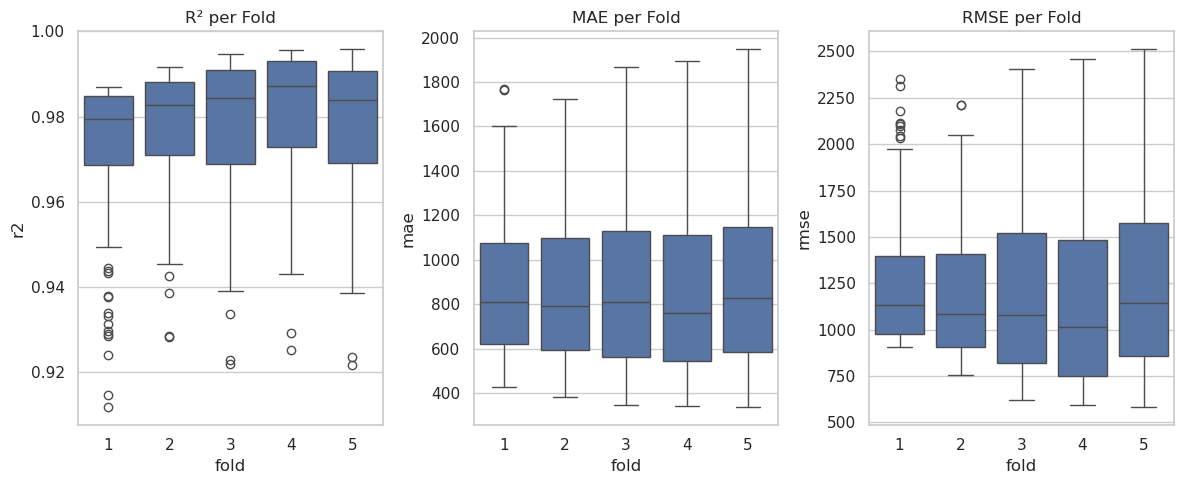

In [74]:
# Visualize
sns.set(style="whitegrid")

# Boxplots
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(x='fold', y='r2', data=metrics_df_xgboost)
plt.title('R² per Fold')

plt.subplot(1,3,2)
sns.boxplot(x='fold', y='mae', data=metrics_df_xgboost)
plt.title('MAE per Fold')

plt.subplot(1,3,3)
sns.boxplot(x='fold', y='rmse', data=metrics_df_xgboost)
plt.title('RMSE per Fold')

plt.tight_layout()
plt.show()

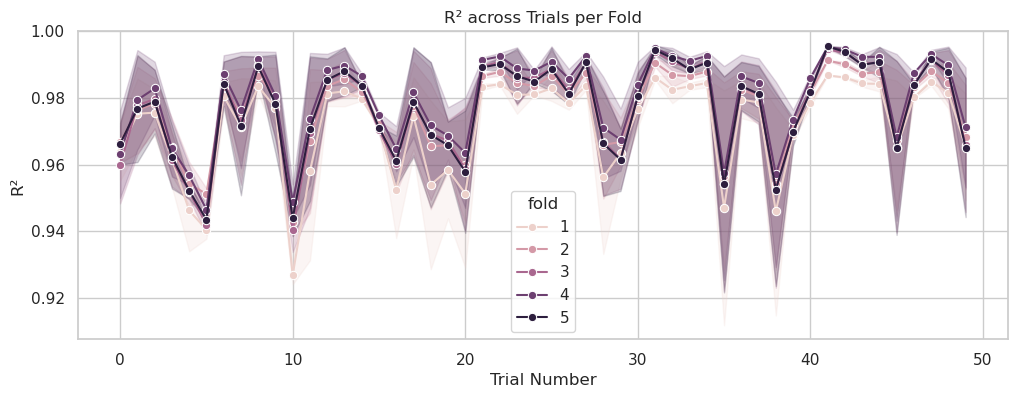

In [75]:
# Line plots: metric trend across trials
plt.figure(figsize=(12,4))
sns.lineplot(x='trial_number', y='r2', hue='fold', data=metrics_df_xgboost, marker='o')
plt.title("R² across Trials per Fold")
plt.xlabel("Trial Number")
plt.ylabel("R²")
plt.show()

In [76]:
# Have to do paired test for different fold
# Example: ANOVA to check if R² differs significantly between folds
fold_r2_groups = [metrics_df_xgboost[metrics_df_xgboost['fold']==f]['r2'] for f in metrics_df_xgboost['fold'].unique()]
anova_result = f_oneway(*fold_r2_groups)
print("\nANOVA for R² across folds")
print(f"F-statistic: {anova_result.statistic:.4f}, p-value: {anova_result.pvalue:.4f}")

# Paired t-test example: fold 1 vs fold 2 R²
t_stat, p_val = ttest_rel(metrics_df_xgboost[metrics_df_xgboost['fold']==1]['r2'].values,
                          metrics_df_xgboost[metrics_df_xgboost['fold']==2]['r2'].values)
print("\nPaired t-test Fold 1 vs Fold 2 R²:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


ANOVA for R² across folds
F-statistic: 2.7730, p-value: 0.0267

Paired t-test Fold 1 vs Fold 2 R²:
t-statistic: -11.0547, p-value: 0.0000


In [77]:
# 7. Confidence intervals
def compute_ci(data, confidence=0.95):
    mean = np.mean(data)
    sem  = stats.sem(data)
    ci_lower, ci_upper = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    return mean, ci_lower, ci_upper

print("\n95% Confidence Intervals ")
for metric in ['r2','mae','rmse']:
    mean, ci_lower, ci_upper = compute_ci(metrics_df_xgboost[metric])
    print(f"{metric}: Mean={mean:.4f}, 95% CI=({ci_lower:.4f}, {ci_upper:.4f})")


95% Confidence Intervals 
r2: Mean=0.9764, 95% CI=(0.9748, 0.9779)
mae: Mean=881.4833, 95% CI=(848.7824, 914.1843)
rmse: Mean=1228.6761, 95% CI=(1188.8548, 1268.4973)


## Feed Forward Neural Network

* The plot shows AC Power as the output and Temperature/Irradiation as inputs. The relationships appear nonlinear.
* Ambient temperature and module temperature have overlapping but distinct patterns.
* Irradiation seems to have a strong positive correlation with AC power, but the spread suggests nonlinear effects.
* FNNs excel at capturing complex nonlinear relationships between inputs and outputs without requiring explicit feature engineering.

The relationship is strongly positive but nonlinear, and it is also a time series data set in which a feed-forward neural network performs better. 
For this part we will use pytorch library to use feed forward neural network and train it.  

## The Code and Innovation

As a part of innovation we will create a neural network with the help of pytorch library then from there we will do prediction and analysis. We will also hypertune with different activation functions to find the best result 

In [78]:
# Device detection 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [79]:
# Global trackers
best_overall_r2_nn = -np.inf
best_overall_train_df_nn = None
best_overall_test_df_nn = None
# Function to get activation function layer
def get_activation(name: str):
    if name == "relu":
        return nn.ReLU()
    elif name == "sigmoid":
        return nn.Sigmoid()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "leaky_relu":
        return nn.LeakyReLU()
    else:
        raise ValueError(f"Unknown activation function: {name}")

In [80]:
# This is our main model which is feed forward neural network
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, hidden_layers, dropout, activation_name):
        super().__init__()
        layers = []

        activation_layer = get_activation(activation_name)

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(activation_layer)
        layers.append(nn.Dropout(dropout))

        # Additional hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(get_activation(activation_name))
            layers.append(nn.Dropout(dropout))

        # Output layer
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

For hyper parameter tuning we will use a bunch of features which includes activation function , learning rate , hidden layers

In [81]:
# Optuna objective
def objective_nn(trial, metrics_csv="fold_metrics_nn.csv"):
    global best_overall_r2_nn, best_overall_train_df_nn, best_overall_test_df_nn

    # Add activation function as hyperparameter
    params = {
        "hidden_dim": trial.suggest_int("hidden_dim", 32, 512),
        "hidden_layers": trial.suggest_int("hidden_layers", 1, 5),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "activation": trial.suggest_categorical("activation", ["relu", "sigmoid", "tanh", "leaky_relu"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-3),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        "epochs": trial.suggest_int("epochs", 20, 200)
    }

    fold_metrics = []

    # Group K-Fold
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        # Extract
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]

        # Convert to tensors
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)
        X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

        # DataLoader
        train_ds = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)

        # Build model
        model = FeedForwardNN(
            input_dim=X_train.shape[1],
            hidden_dim=params["hidden_dim"],
            hidden_layers=params["hidden_layers"],
            dropout=params["dropout"],
            activation_name=params["activation"]
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"])
        loss_fn = nn.MSELoss()

        # Training loop
        model.train()
        for epoch in range(params["epochs"]):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                preds = model(xb)
                loss = loss_fn(preds, yb)
                loss.backward()
                optimizer.step()

        # Prediction
        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().reshape(-1,1)

        # Inverse scaling
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1,1))

        # Metrics
        r2 = r2_score(real_y, preds)
        mae = mean_absolute_error(real_y, preds)
        rmse = np.sqrt(mean_squared_error(real_y, preds))

        fold_metrics.append({
            "fold": fold_data["fold"],
            "r2": r2,
            "mae": mae,
            "rmse": rmse
        })

        # Save best
        if r2 > best_overall_r2_nn:
            best_overall_r2_nn = r2
            best_overall_train_df_nn = fold_data["train_df"]
            best_overall_test_df_nn  = fold_data["test_df"]

    # Save CSV
    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df["trial_number"] = trial.number
    fold_metrics_df.to_csv(metrics_csv, mode='a', index=False,
                           header=not pd.io.common.file_exists(metrics_csv))

    mean_r2 = np.mean([m["r2"] for m in fold_metrics])

    trial.set_user_attr("mean_mae", np.mean([m["mae"] for m in fold_metrics]))
    trial.set_user_attr("mean_rmse", np.mean([m["rmse"] for m in fold_metrics]))

    return mean_r2

In [82]:
# Create study  Bayesian optimization for Neural Network
study_nn = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler()
)

# Run optimization
study_nn.optimize(objective_nn, n_trials=50, show_progress_bar=True)

# Best trial
best_trial_nn = study_nn.best_trial

print("Best Trial Results (Neural Network)")
print("Mean R² Score across folds:", best_trial_nn.value)
print("Mean MAE across folds :", best_trial_nn.user_attrs["mean_mae"])
print("Mean RMSE across folds:", best_trial_nn.user_attrs["mean_rmse"])

print("\nBest Hyperparameters:")
for k, v in best_trial_nn.params.items():
    print(f"  {k}: {v}")

# Save the global best dataset after all trials
if best_overall_train_df_nn is not None and best_overall_test_df_nn is not None:
    best_overall_train_df_nn.to_csv("best_train_dataset_neural_network.csv", index=False)
    best_overall_test_df_nn.to_csv("best_test_dataset_neural_network.csv", index=False)
    print("Best train/test datasets saved with highest R² score:", best_overall_r2_nn)

print("\nBest train/test datasets with highest R² across all NN trials saved to CSV.")
best_train_path_nn = "best_train_dataset_neural_network.csv"
best_test_path_nn  = "best_test_dataset_neural_network.csv"
print("Train dataset:", best_train_path_nn)
print("Test dataset :", best_test_path_nn)

# Optional: load it to check shape
best_train_df_nn = pd.read_csv(best_train_path_nn)
best_test_df_nn  = pd.read_csv(best_test_path_nn)
print("Train shape:", best_train_df_nn.shape)
print("Test shape :", best_test_df_nn.shape)


[I 2025-12-01 08:37:59,852] A new study created in memory with name: no-name-8243c06b-19d4-4b34-b667-0f30096c9221


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-01 08:39:17,008] Trial 0 finished with value: 0.9939492396350669 and parameters: {'hidden_dim': 94, 'hidden_layers': 3, 'dropout': 0.026741777904760178, 'activation': 'tanh', 'learning_rate': 0.0015891689094839174, 'batch_size': 64, 'epochs': 166}. Best is trial 0 with value: 0.9939492396350669.
[I 2025-12-01 08:39:47,550] Trial 1 finished with value: -0.04007327970884487 and parameters: {'hidden_dim': 443, 'hidden_layers': 5, 'dropout': 0.4978482791748793, 'activation': 'sigmoid', 'learning_rate': 0.003618907454689957, 'batch_size': 256, 'epochs': 24}. Best is trial 0 with value: 0.9939492396350669.
[I 2025-12-01 08:40:53,591] Trial 2 finished with value: 0.9804213338388437 and parameters: {'hidden_dim': 259, 'hidden_layers': 3, 'dropout': 0.20555918656814487, 'activation': 'leaky_relu', 'learning_rate': 0.004578662116007772, 'batch_size': 512, 'epochs': 173}. Best is trial 0 with value: 0.9939492396350669.
[I 2025-12-01 08:42:11,369] Trial 3 finished with value: 0.99134646

In [83]:
# Prediction on the neural network that we have developed

# Loading best hyperparameters

best_params_nn = best_trial_nn.params.copy()

hidden_dim     = best_params_nn["hidden_dim"]
hidden_layers  = best_params_nn["hidden_layers"]
dropout        = best_params_nn["dropout"]
activation     = best_params_nn["activation"]
learning_rate  = best_params_nn["learning_rate"]
batch_size     = best_params_nn["batch_size"]
epochs         = best_params_nn["epochs"]

# Load best train/test dataset

best_train_df = pd.read_csv("best_train_dataset_neural_network.csv")
best_test_df  = pd.read_csv("best_test_dataset_neural_network.csv")

X_train = best_train_df[features].values
y_train = best_train_df["AC_POWER"].values.ravel()

X_test  = best_test_df[features].values
y_test  = best_test_df["AC_POWER"].values.ravel()


# Scaling target (use same scaler as training system)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))


# Convert to PyTorch tensors

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)

X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)


# Build final NN model

final_nn_model = FeedForwardNN(
    input_dim=X_train.shape[1],
    hidden_dim=hidden_dim,
    hidden_layers=hidden_layers,
    dropout=dropout,
    activation_name=activation
).to(device)

optimizer = optim.Adam(final_nn_model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()


# Training loop

final_nn_model.train()
for epoch in range(epochs):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = final_nn_model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()


# Prediction

final_nn_model.eval()
with torch.no_grad():
    preds_scaled = final_nn_model(X_test_t).cpu().numpy().reshape(-1, 1)


# Inverse scaling back to original values

final_pred_nn = y_scaler.inverse_transform(preds_scaled)


# Evaluate performance

final_r2   = r2_score(y_test, final_pred_nn)
final_mae  = mean_absolute_error(y_test, final_pred_nn)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred_nn))

print("Final Neural Network R² :", final_r2)
print("Final Neural Network MAE:", final_mae)
print("Final Neural Network RMSE:", final_rmse)


Final Neural Network R² : 0.9937188328961247
Final Neural Network MAE: 513.4773545481218
Final Neural Network RMSE: 711.0355627542474


### Graphical Analysis

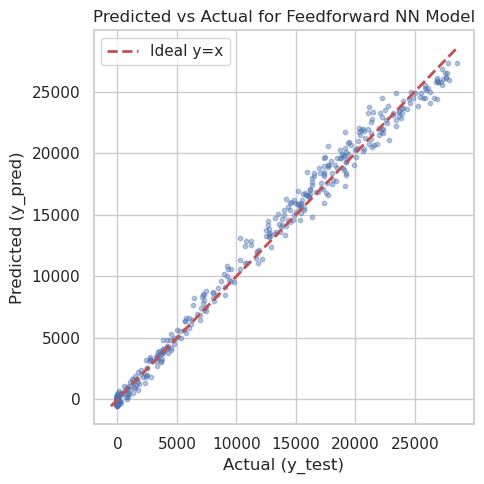

In [84]:

# Scatter Plot: Predicted vs Actual

plt.figure(figsize=(5,5))
plt.scatter(y_test, final_pred_nn, s=10, alpha=0.4)
lo, hi = min(np.min(y_test), np.min(final_pred_nn)), max(np.max(y_test), np.max(final_pred_nn))
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal y=x')
plt.xlabel('Actual (y_test)')
plt.ylabel('Predicted (y_pred)')
plt.title('Predicted vs Actual for Feedforward NN Model')
plt.legend()
plt.tight_layout()
plt.show()


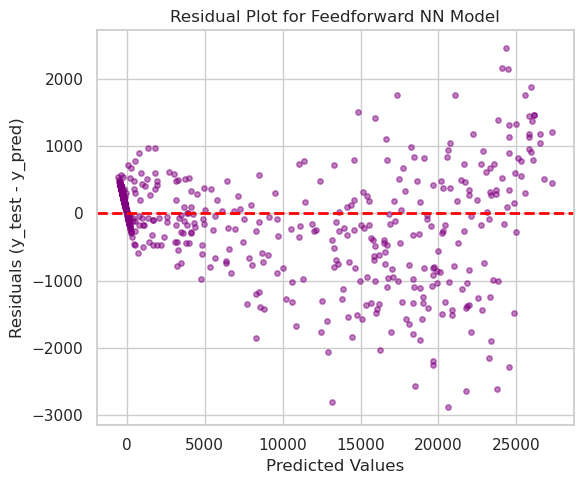

In [85]:

# Residual Plot
y_test_aligned = np.array(y_test).flatten()
y_pred_aligned = np.array(final_pred_nn).flatten()

residuals = y_test_aligned - y_pred_aligned

plt.figure(figsize=(6,5))
plt.scatter(y_pred_aligned, residuals, alpha=0.5, s=15, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residual Plot for Feedforward NN Model')
plt.grid(True)
plt.tight_layout()
plt.show()


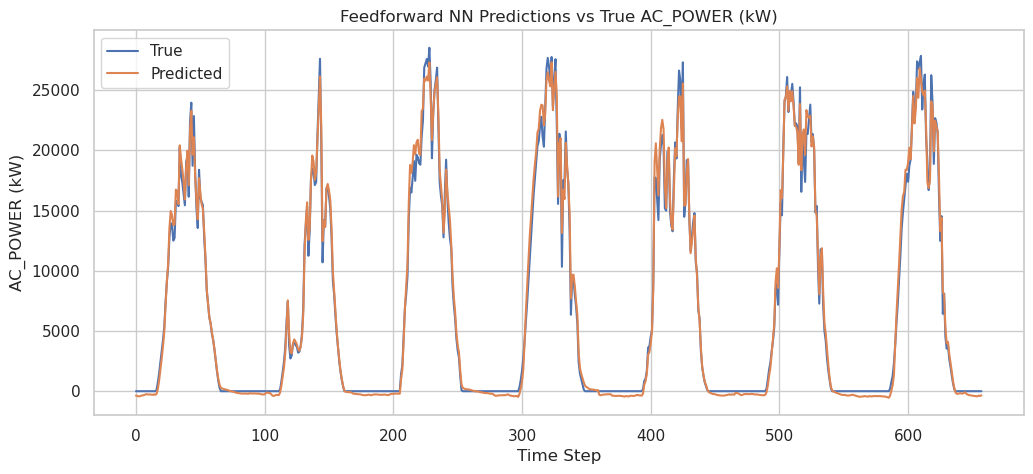

In [86]:
# Time Series Plot: True vs Predicted
plt.figure(figsize=(12,5))
plt.plot(y_test, label='True')
plt.plot(final_pred_nn, label='Predicted')
plt.legend()
plt.title('Feedforward NN Predictions vs True AC_POWER (kW)')
plt.xlabel('Time Step')
plt.ylabel('AC_POWER (kW)')
plt.show()

### Statistical Analysis for Feed Forward Neural Network

In [87]:
# 1. Load fold metrics CSV

metrics_csv = "fold_metrics_nn.csv"  # Change if needed
metrics_df_nn = pd.read_csv(metrics_csv)
metrics_df_nn

,fold,r2,mae,rmse,trial_number
0,1,0.985181,540.107599,963.463872,0
1,2,0.987346,657.687662,930.141827,0
2,3,0.985982,877.305507,1018.111413,0
3,4,0.993711,560.697842,713.520031,0
4,5,0.994176,520.145610,684.656066,0
...,...,...,...,...,...
495,1,0.982954,423.664115,1033.332652,49
496,2,0.993007,360.706652,691.456668,49
497,3,0.995722,299.486446,562.410630,49
498,4,0.995893,322.109556,576.605603,49


In [88]:
# Describe 
desc_stats_nn = metrics_df_nn[['r2','mae','rmse']].describe()
desc_stats_nn

,r2,mae,rmse
count,500.000000,500.000000,500.000000
mean,0.963514,669.976491,1005.990525
std,0.157328,1121.932935,1276.855980
min,-0.136632,270.290948,483.340445
25%,0.987345,351.261645,580.913776
50%,0.992708,405.762248,720.246241
75%,0.995675,563.044717,917.809667
max,0.997098,7838.197417,9113.774703


In [89]:
fold_stats_nn = metrics_df_nn.groupby('fold')[['r2','mae','rmse']].agg(['mean','std','min','max'])
fold_stats_nn

r2                                       mae               \
          mean       std       min       max        mean          std   
fold                                                                    
1     0.955113  0.172262 -0.136632  0.989621  694.557424  1069.612570   
2     0.960641  0.163499 -0.028610  0.993675  695.687064  1172.956582   
3     0.966077  0.148644 -0.004346  0.996212  656.107782  1100.888779   
4     0.973443  0.133746 -0.026091  0.996801  613.356511  1020.883187   
5     0.962298  0.167880 -0.029602  0.997098  690.173671  1251.137931   

                                      rmse                           \
             min          max         mean          std         min   
fold                                                                  
1     354.123963  7667.449879  1167.261854  1209.906123  806.309372   
2     307.007612  7562.944663  1045.210793  1270.677813  657.625853   
3     279.680107  7337.625071   951.689160  1272.376853  529.246664   
4     270.971004  7725.661988   880.719234  1178.127694  508.858110   
5     270.290948  7838.197417   985.071586  1444.008215  483.340445   

                   
              max  
fold               
1     8437.962165  
2     8386.053848  
3     8617.795085  
4     9113.774703  
5     9103.448392

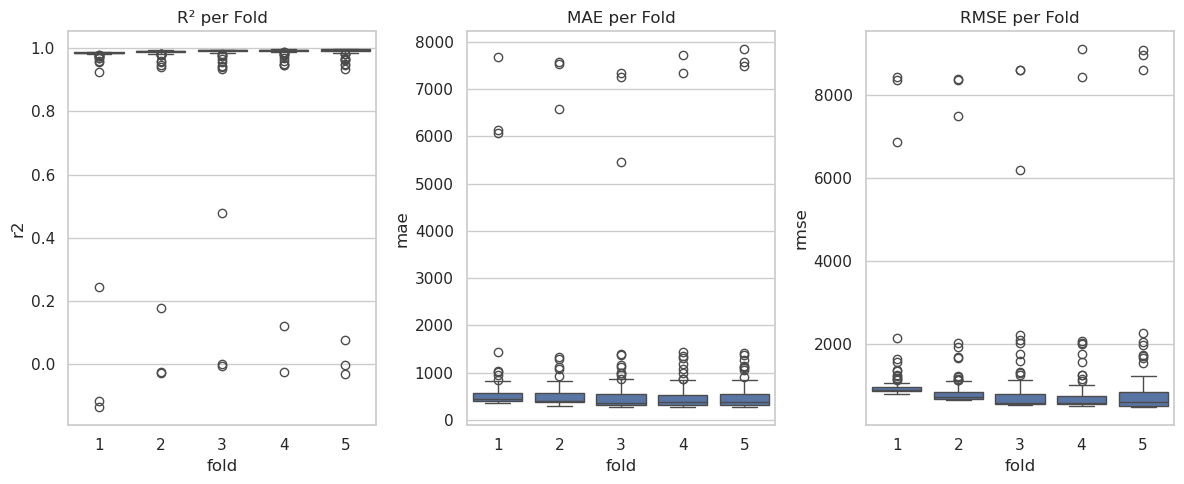

In [90]:
# Visualize
sns.set(style="whitegrid")

# Boxplots
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(x='fold', y='r2', data=metrics_df_nn)
plt.title('R² per Fold')

plt.subplot(1,3,2)
sns.boxplot(x='fold', y='mae', data=metrics_df_nn)
plt.title('MAE per Fold')

plt.subplot(1,3,3)
sns.boxplot(x='fold', y='rmse', data=metrics_df_nn)
plt.title('RMSE per Fold')

plt.tight_layout()
plt.show()

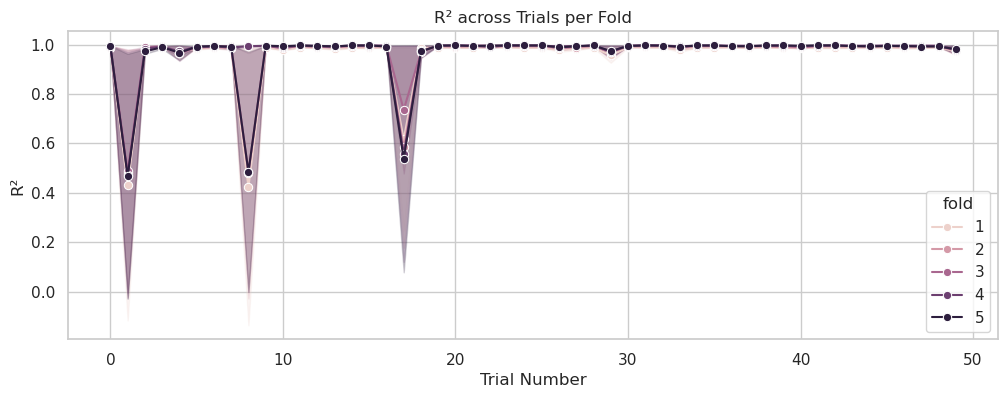

In [91]:
# Line plots: metric trend across trials
plt.figure(figsize=(12,4))
sns.lineplot(x='trial_number', y='r2', hue='fold', data=metrics_df_nn, marker='o')
plt.title("R² across Trials per Fold")
plt.xlabel("Trial Number")
plt.ylabel("R²")
plt.show()

In [92]:
# Example: ANOVA to check if R² differs significantly between folds
fold_r2_groups = [metrics_df_nn[metrics_df_nn['fold']==f]['r2'] for f in metrics_df_nn['fold'].unique()]
anova_result = f_oneway(*fold_r2_groups)
print("\nANOVA for R² across folds")
print(f"F-statistic: {anova_result.statistic:.4f}, p-value: {anova_result.pvalue:.4f}")

# Paired t-test example: fold 1 vs fold 2 R²
t_stat, p_val = ttest_rel(metrics_df_nn[metrics_df_nn['fold']==1]['r2'].values,
                          metrics_df_nn[metrics_df_nn['fold']==2]['r2'].values)
print("\nPaired t-test Fold 1 vs Fold 2 R²:")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


ANOVA for R² across folds
F-statistic: 0.1861, p-value: 0.9456

Paired t-test Fold 1 vs Fold 2 R²:
t-statistic: -3.3999, p-value: 0.0010


In [93]:
# 7. Confidence intervals
def compute_ci(data, confidence=0.95):
    mean = np.mean(data)
    sem  = stats.sem(data)
    ci_lower, ci_upper = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    return mean, ci_lower, ci_upper

print("\n95% Confidence Intervals ")
for metric in ['r2','mae','rmse']:
    mean, ci_lower, ci_upper = compute_ci(metrics_df_nn[metric])
    print(f"{metric}: Mean={mean:.4f}, 95% CI=({ci_lower:.4f}, {ci_upper:.4f})")


95% Confidence Intervals 
r2: Mean=0.9635, 95% CI=(0.9497, 0.9773)
mae: Mean=669.9765, 95% CI=(571.3974, 768.5555)
rmse: Mean=1005.9905, 95% CI=(893.7991, 1118.1819)


In [94]:
best_row = metrics_df.loc[metrics_df['r2'].idxmax()]
print("\n Best Trial/Fold")
print(best_row)
print(f"Trial {best_row['trial_number']} - Fold {best_row['fold']} has the highest R²: {best_row['r2']:.4f}")


 Best Trial/Fold
fold              4.000000
r2                0.996549
mae             277.285993
rmse            528.559489
trial_number     19.000000
Name: 348, dtype: float64
Trial 19.0 - Fold 4.0 has the highest R²: 0.9965


# Model Comparison and Statistical Analysis

## Running models for different k fold 

As now we have got the best hyper parameters using that hyper parameter for different k fold we will extract different results which are r square , rmse and mae. We will keep those results in a csv and run statistical analysis

## Generating Results for Random Forest

We will extract the hyper parameters from optuna beysian study at first

In [114]:
# Extracting the best hyper parameters for random forest
best_params_rf = study_rf.best_trial.params
print(best_params_rf)

{'n_estimators': 1023, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.9993452307663965, 'bootstrap': True}


In [96]:
best_params_rf = study_rf.best_trial.params

# RandomForest requires these additional parameters:
best_params_rf["random_state"] = None       # allow randomness for repeated runs
best_params_rf["n_jobs"] = -1               # use all CPU cores

print("Loaded Hyperparameters:", best_params_rf)

# Output CSV file

output_csv = "rf_repeated_final_metrics.csv"

# Initialize CSV with headers
pd.DataFrame(columns=["fold", "r2", "mae", "rmse", "trial_number"]).to_csv(
    output_csv, index=False
)

# Run Repeated Group K-Fold
NUM_REPEATS = 50

global_trial_num = 0

for repeat in range(NUM_REPEATS):
    print(f"Running repetition {repeat + 1} of {NUM_REPEATS}...")

    best_params_rf["random_state"] = repeat
    best_params_rf["n_jobs"] = -1  # Use all CPUs

    fold_metrics = []
    
    # Perform group k-fold split (5 folds)
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]


        # Train Random Forest
        model = RandomForestRegressor(**best_params_rf)
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test).reshape(-1, 1)
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1,1))

        # Metrics
        r2     = r2_score(real_y, preds)
        mae    = mean_absolute_error(real_y, preds)
        rmse   = np.sqrt(mean_squared_error(real_y, preds))

        # Append row to CSV

        row = pd.DataFrame([{
            "fold": fold_data["fold"] + 1,  # show fold as 1–5
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "trial_number": repeat
        }])

        row.to_csv(output_csv, mode="a", header=False, index=False)

        global_trial_num += 1

print("\nFinished 50 repeated runs!")
print("Saved to:", output_csv)

Loaded Hyperparameters: {'n_estimators': 1023, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.9993452307663965, 'bootstrap': True, 'random_state': None, 'n_jobs': -1}
Running repetition 1 of 50...
Running repetition 2 of 50...
Running repetition 3 of 50...
Running repetition 4 of 50...
Running repetition 5 of 50...
Running repetition 6 of 50...
Running repetition 7 of 50...
Running repetition 8 of 50...
Running repetition 9 of 50...
Running repetition 10 of 50...
Running repetition 11 of 50...
Running repetition 12 of 50...
Running repetition 13 of 50...
Running repetition 14 of 50...
Running repetition 15 of 50...
Running repetition 16 of 50...
Running repetition 17 of 50...
Running repetition 18 of 50...
Running repetition 19 of 50...
Running repetition 20 of 50...
Running repetition 21 of 50...
Running repetition 22 of 50...
Running repetition 23 of 50...
Running repetition 24 of 50...
Running repetition 25 of 50...
Running repetition 26 of 50...
R

## Generating Results for XGBoost Regressor

In [97]:
# Extracting the best hyper parameters for xgboost
best_params_xgb = study_xgb.best_trial.params
print(best_params_xgb)

{'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.06047377808993283, 'subsample': 0.8477157271425722, 'colsample_bytree': 0.6967216045025879, 'gamma': 0.007165477296329704, 'reg_alpha': 0.2716805884610348, 'reg_lambda': 0.35915197683882905}


In [98]:
best_params_rf = study_xgb.best_trial.params

# RandomForest requires these additional parameters:
best_params_rf["random_state"] = None       # allow randomness for repeated runs
best_params_rf["n_jobs"] = -1               # use all CPU cores

print("Loaded Hyperparameters:", best_params_rf)

# Output CSV file

output_csv = "xgb_repeated_final_metrics.csv"

# Initialize CSV with headers
pd.DataFrame(columns=["fold", "r2", "mae", "rmse", "trial_number"]).to_csv(
    output_csv, index=False
)

# Run Repeated Group K-Fold
NUM_REPEATS = 50

global_trial_num = 0

for repeat in range(NUM_REPEATS):
    print(f"Running repetition {repeat + 1} of {NUM_REPEATS}...")

    best_params_rf["random_state"] = repeat
    best_params_rf["n_jobs"] = -1  # Use all CPUs

    fold_metrics = []
    
    # Perform group k-fold split (5 folds)
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]


        # Train Random Forest
        model = xgb.XGBRegressor(**best_params_rf)
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test).reshape(-1, 1)
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1,1))

        # Metrics
        r2     = r2_score(real_y, preds)
        mae    = mean_absolute_error(real_y, preds)
        rmse   = np.sqrt(mean_squared_error(real_y, preds))

        # Append row to CSV

        row = pd.DataFrame([{
            "fold": fold_data["fold"] + 1,  # show fold as 1–5
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "trial_number": repeat
        }])

        row.to_csv(output_csv, mode="a", header=False, index=False)

        global_trial_num += 1

print("\nFinished 50 repeated runs!")
print("Saved to:", output_csv)

Loaded Hyperparameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.06047377808993283, 'subsample': 0.8477157271425722, 'colsample_bytree': 0.6967216045025879, 'gamma': 0.007165477296329704, 'reg_alpha': 0.2716805884610348, 'reg_lambda': 0.35915197683882905, 'random_state': None, 'n_jobs': -1}
Running repetition 1 of 50...
Running repetition 2 of 50...
Running repetition 3 of 50...
Running repetition 4 of 50...
Running repetition 5 of 50...
Running repetition 6 of 50...
Running repetition 7 of 50...
Running repetition 8 of 50...
Running repetition 9 of 50...
Running repetition 10 of 50...
Running repetition 11 of 50...
Running repetition 12 of 50...
Running repetition 13 of 50...
Running repetition 14 of 50...
Running repetition 15 of 50...
Running repetition 16 of 50...
Running repetition 17 of 50...
Running repetition 18 of 50...
Running repetition 19 of 50...
Running repetition 20 of 50...
Running repetition 21 of 50...
Running repetition 22 of 50...
Running repetition 

## Generating Results for Feed Forward Neural Network

In [99]:
# Extracting the best hyper parameters for feed forward neural network
best_params_nn = study_nn.best_trial.params
print(best_params_nn)

{'hidden_dim': 105, 'hidden_layers': 2, 'dropout': 0.157239169545604, 'activation': 'tanh', 'learning_rate': 0.0012736670770171989, 'batch_size': 512, 'epochs': 152}


In [100]:
# Load best hyperparameters from Optuna for FFNN
best_params_nn = study_nn.best_trial.params
print("Loaded Hyperparameters:", best_params_nn)

# Output CSV file
output_csv = "ffnn_repeated_final_metrics.csv"

# Initialize CSV with headers
pd.DataFrame(columns=["fold", "r2", "mae", "rmse", "trial_number"]).to_csv(
    output_csv, index=False
)

# Number of repeated runs
NUM_REPEATS = 50

for repeat in range(NUM_REPEATS):
    print(f"Running repetition {repeat + 1} of {NUM_REPEATS}...")

    fold_metrics = []

    # Perform group k-fold split (5 folds)
    for fold_data in group_kfold_split_by_date(
        df,
        date_col="DATE",
        feature_cols=features,
        target_col="AC_POWER",
        n_splits=5
    ):
        X_train = fold_data["X_train"]
        X_test  = fold_data["X_test"]
        y_train = fold_data["y_train"].ravel()
        y_test  = fold_data["y_test"].ravel()
        y_scaler = fold_data["y_scaler"]

        # Convert to tensors
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)
        X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

        # DataLoader
        train_ds = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_ds, batch_size=best_params_nn["batch_size"], shuffle=True)

        # Build model with best hyperparameters
        model = FeedForwardNN(
            input_dim=X_train.shape[1],
            hidden_dim=best_params_nn["hidden_dim"],
            hidden_layers=best_params_nn["hidden_layers"],
            dropout=best_params_nn["dropout"],
            activation_name=best_params_nn["activation"]
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=best_params_nn["learning_rate"])
        loss_fn = nn.MSELoss()

        # Set random seed for reproducibility per repetition
        torch.manual_seed(repeat)
        np.random.seed(repeat)

        # Training loop
        model.train()
        for epoch in range(best_params_nn["epochs"]):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                preds = model(xb)
                loss = loss_fn(preds, yb)
                loss.backward()
                optimizer.step()

        # Prediction
        model.eval()
        with torch.no_grad():
            preds = model(X_test_t).cpu().numpy().reshape(-1,1)

        # Inverse scaling
        preds = y_scaler.inverse_transform(preds)
        real_y = y_scaler.inverse_transform(y_test.reshape(-1,1))

        # Metrics
        r2   = r2_score(real_y, preds)
        mae  = mean_absolute_error(real_y, preds)
        rmse = np.sqrt(mean_squared_error(real_y, preds))

        # Append row to CSV
        row = pd.DataFrame([{
            "fold": fold_data["fold"] + 1,
            "r2": r2,
            "mae": mae,
            "rmse": rmse,
            "trial_number": repeat
        }])
        row.to_csv(output_csv, mode="a", header=False, index=False)

print("\nFinished 50 repeated runs!")
print("Saved to:", output_csv)


Loaded Hyperparameters: {'hidden_dim': 105, 'hidden_layers': 2, 'dropout': 0.157239169545604, 'activation': 'tanh', 'learning_rate': 0.0012736670770171989, 'batch_size': 512, 'epochs': 152}
Running repetition 1 of 50...
Running repetition 2 of 50...
Running repetition 3 of 50...
Running repetition 4 of 50...
Running repetition 5 of 50...
Running repetition 6 of 50...
Running repetition 7 of 50...
Running repetition 8 of 50...
Running repetition 9 of 50...
Running repetition 10 of 50...
Running repetition 11 of 50...
Running repetition 12 of 50...
Running repetition 13 of 50...
Running repetition 14 of 50...
Running repetition 15 of 50...
Running repetition 16 of 50...
Running repetition 17 of 50...
Running repetition 18 of 50...
Running repetition 19 of 50...
Running repetition 20 of 50...
Running repetition 21 of 50...
Running repetition 22 of 50...
Running repetition 23 of 50...
Running repetition 24 of 50...
Running repetition 25 of 50...
Running repetition 26 of 50...
Running repet

In [101]:
# Load all metrics
# Combining all metrics
rf_df  = pd.read_csv("rf_repeated_final_metrics.csv")
xgb_df = pd.read_csv("xgb_repeated_final_metrics.csv")
nn_df  = pd.read_csv("ffnn_repeated_final_metrics.csv")

# Add model name to each dataframe
rf_df["model"]  = "Random Forest"
xgb_df["model"] = "XGBoost"
nn_df["model"]  = "Feed Forward Neural Network"

# Combine all data
all_df = pd.concat([rf_df, xgb_df, nn_df], ignore_index=True)

# Display combined table
print("\nCombined Metrics")
print(all_df.head())


Combined Metrics
   fold        r2         mae        rmse  trial_number          model
0     2  0.988748  347.761539  839.531864             0  Random Forest
1     3  0.992876  315.928857  697.911414             0  Random Forest
2     4  0.995310  292.502991  588.884337             0  Random Forest
3     5  0.996558  276.772853  527.858722             0  Random Forest
4     6  0.996412  272.845377  537.403386             0  Random Forest


In [111]:
# Computing average metrics per model
mean_metrics = all_df.groupby("model")[["r2", "mae", "rmse"]].agg(["mean", "std"])
print("\nMean Performance Per Model")
mean_metrics


Mean Performance Per Model


r2                   mae             \
                                 mean       std        mean        std   
model                                                                    
Feed Forward Neural Network  0.993721  0.003504  358.636269  58.531696   
Random Forest                0.993991  0.002917  301.260229  27.565197   
XGBoost                      0.991622  0.003639  409.553336  39.699124   

                                   rmse              
                                   mean         std  
model                                                
Feed Forward Neural Network  646.864575  138.503634  
Random Forest                638.060804  116.465891  
XGBoost                      758.209377  124.055122

In [103]:
rank_table = all_df.groupby("model").agg(
    r2_mean=("r2", "mean"),
    rmse_mean=("rmse", "mean"),
    mae_mean=("mae", "mean")
).sort_values(by="rmse_mean")

print("\nModel Ranking (Based on RMSE)")
print(rank_table)



Model Ranking (Based on RMSE)
                              r2_mean   rmse_mean    mae_mean
model                                                        
Random Forest                0.993991  638.060804  301.260229
Feed Forward Neural Network  0.993721  646.864575  358.636269
XGBoost                      0.991622  758.209377  409.553336


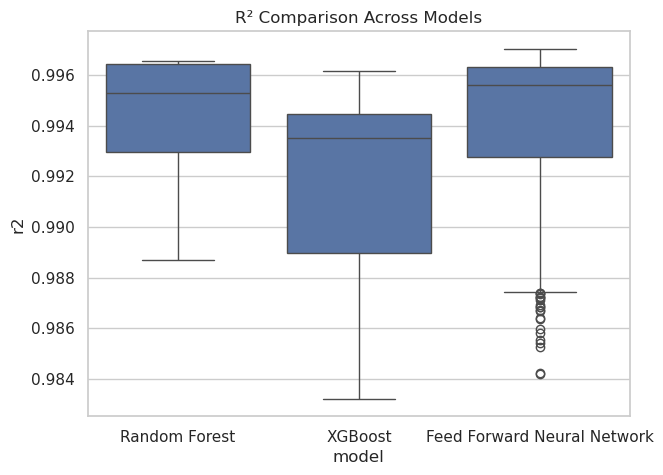

In [104]:
# Box plot of r square comparison for different models
plt.figure(figsize=(7,5))
sns.boxplot(data=all_df, x="model", y="r2")
plt.title("R² Comparison Across Models")
plt.show()


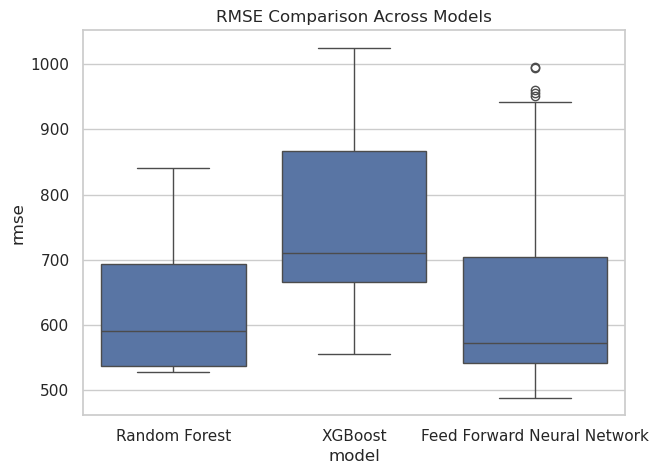

In [105]:
# Box plot of rmse comparison between 3 different models
plt.figure(figsize=(7,5))
sns.boxplot(data=all_df, x="model", y="rmse")
plt.title("RMSE Comparison Across Models")
plt.show()


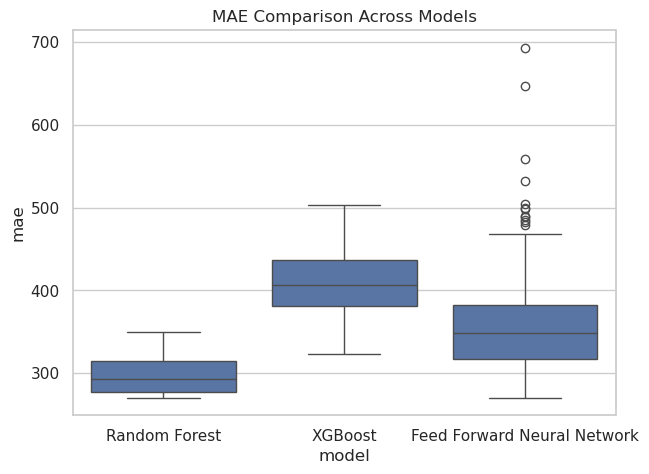

In [106]:
# Box plot of mae for different models
plt.figure(figsize=(7,5))
sns.boxplot(data=all_df, x="model", y="mae")
plt.title("MAE Comparison Across Models")
plt.show()


In [107]:
# Statistical significance test
rf_r2  = rf_df["r2"].values
xgb_r2 = xgb_df["r2"].values
nn_r2  = nn_df["r2"].values

stat, p = friedmanchisquare(rf_r2, xgb_r2, nn_r2)

print("\nFriedman Test for R²")
print("Statistic:", stat)
print("p-value:", p)



Friedman Test for R²
Statistic: 351.22400000000016
p-value: 5.403528469929651e-77


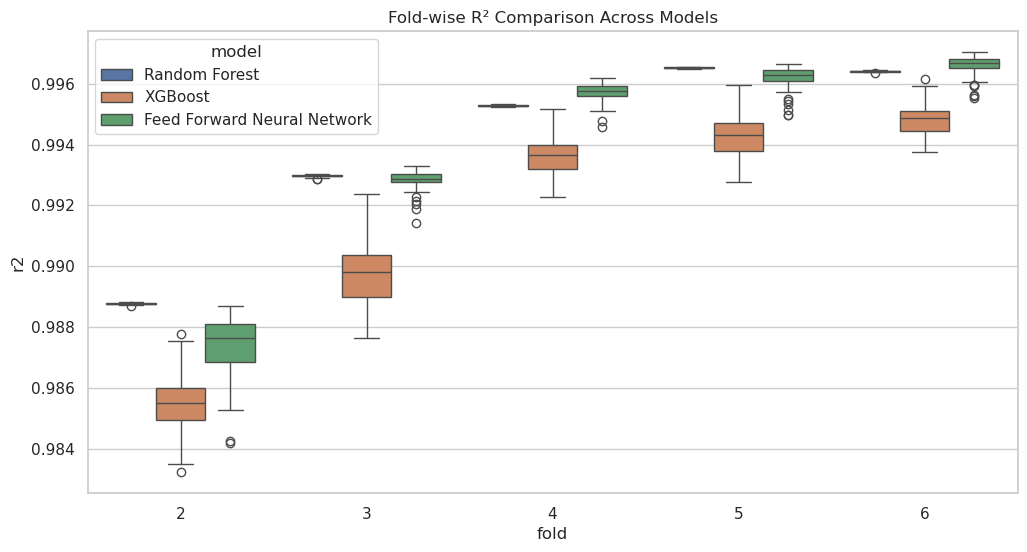

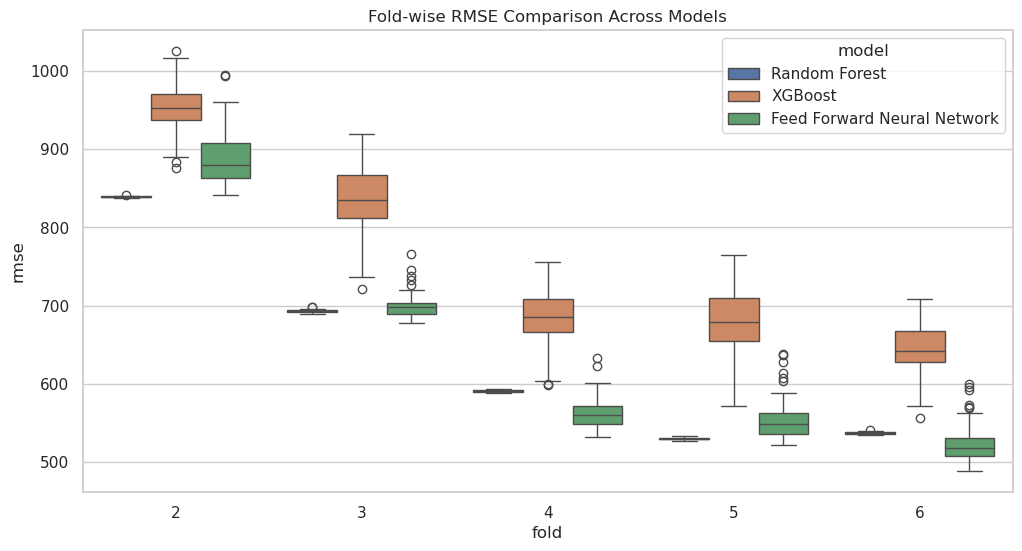

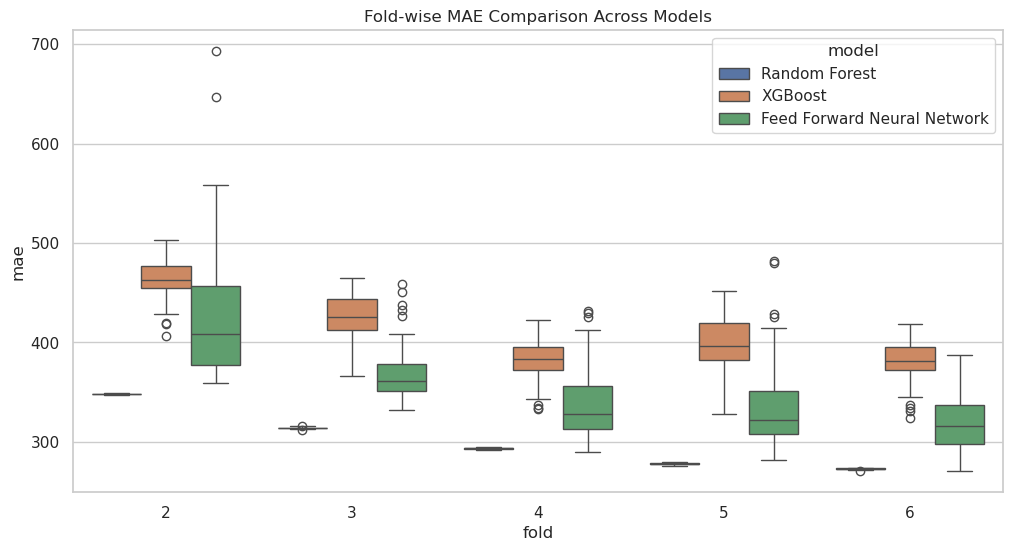

In [108]:
# Fold wise comparison for different models
plt.figure(figsize=(12, 6))
sns.boxplot(data=all_df, x="fold", y="r2", hue="model")
plt.title("Fold-wise R² Comparison Across Models")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=all_df, x="fold", y="rmse", hue="model")
plt.title("Fold-wise RMSE Comparison Across Models")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=all_df, x="fold", y="mae", hue="model")
plt.title("Fold-wise MAE Comparison Across Models")
plt.show()

## Analysis

Random Forest is the best model overall for this dataset.

* It has the highest mean R² (0.993991), slightly better than the Feed Forward Neural Network (0.993721) and clearly better than XGBoost (0.991622), so it explains the most variance on average.

* It also achieves the lowest mean RMSE (638.06) and the lowest mean MAE (301.26), meaning its prediction errors are both smaller and more accurate than the other models.

* Its standard deviations for MAE and RMSE are smaller than those of the neural network and XGBoost, so its performance is more stable across folds.

* The Friedman test statistic (351.224) with an extremely small p‑value (~5.4×10⁻⁷⁷) confirms that the differences between models are statistically significant, not due to chance.


From the boxplots, Random Forest is clearly the strongest and most stable model.

* In the overall RMSE and MAE boxplots, Random Forest has the lowest median error and the narrowest boxes, meaning its typical errors are smaller and less variable than XGBoost and the neural network.

* XGBoost shows higher medians and taller boxes for both RMSE and MAE, plus more spread and outliers, indicating larger and less consistent errors.

* The Feed Forward Neural Network improves over XGBoost but still has higher MAE and a wider spread than Random Forest, especially with several large-error outliers.

* In the R² boxplots (overall and fold‑wise), Random Forest’s scores are tightly clustered at the top with very small variance, while XGBoost is visibly lower and the neural network has more scatter and a longer lower tail.

* Together, these boxplots show that Random Forest not only achieves the best central performance (lowest errors, highest R²) but also the most consistent performance across folds and runs, which is why it is the preferred model.

# Fitting Testing and Cross Validation

From the analysis we can say that random forest performs better than xgboost and feed forward neural network. Right now we have the tuned hyper parameters. With these hyper parameters we will create a model. We will perform k fold cross validation and based on the analysis if the model is not overfitting we will choose this model and use that for future usage.

Right now we have the best hyper parameters for random forest. We will create a model based on that and will do cross validation. 

In [113]:
# Extracting the best hyper parameters for random forest
best_params_rf = study_rf.best_trial.params
print(best_params_rf)

{'n_estimators': 1023, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.9993452307663965, 'bootstrap': True}


In [115]:
rf_model = RandomForestRegressor(**best_params_rf)

In [116]:
rf_model

,n_estimators,1023
,criterion,'squared_error'
,max_depth,33
,min_samples_split,7
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,0.9993452307663965
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
# Add necessary params
best_params_rf["n_jobs"] = -1        # use all CPU cores
best_params_rf["random_state"] = 42  # fixed seed for reproducibility

print("Using Tuned Hyperparameters:", best_params_rf)

Using Tuned Hyperparameters: {'n_estimators': 1023, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.9993452307663965, 'bootstrap': True, 'n_jobs': -1, 'random_state': 42}


Now we will write the code to evaluate overfitting and cross validation using group k fold

In [139]:
fold_results = []

for fold_data in group_kfold_split_by_date(
    df,
    date_col="DATE",
    feature_cols=features,
    target_col="AC_POWER",
    n_splits=5
):
    fold_num = fold_data["fold"]

    X_train = fold_data["X_train"]
    X_test  = fold_data["X_test"]
    y_train = fold_data["y_train"].ravel()
    y_test  = fold_data["y_test"].ravel()

    y_scaler = fold_data["y_scaler"]

    #Train RF on scaled data
    rf = RandomForestRegressor(**best_params_rf)
    rf.fit(X_train, y_train)

    #Train & Test Predictions
    pred_train = rf.predict(X_train).reshape(-1, 1)
    pred_test  = rf.predict(X_test).reshape(-1, 1)

    #Inverse transform
    pred_train = y_scaler.inverse_transform(pred_train)
    pred_test  = y_scaler.inverse_transform(pred_test)

    real_train = y_scaler.inverse_transform(y_train.reshape(-1,1))
    real_test  = y_scaler.inverse_transform(y_test.reshape(-1,1))

    #Compute metrics
    train_r2 = r2_score(real_train, pred_train)
    test_r2  = r2_score(real_test, pred_test)

    train_mae = mean_absolute_error(real_train, pred_train)
    test_mae  = mean_absolute_error(real_test, pred_test)

    train_rmse = np.sqrt(mean_squared_error(real_train, pred_train))
    test_rmse  = np.sqrt(mean_squared_error(real_test, pred_test))

    fold_results.append({
        "fold": fold_num,
        "train_r2": train_r2, "test_r2": test_r2,
        "train_mae": train_mae, "test_mae": test_mae,
        "train_rmse": train_rmse, "test_rmse": test_rmse,
        "model": rf
    })

# Convert to DataFrame without model
fold_df = pd.DataFrame([{k:v for k,v in fr.items() if k!="model"} for fr in fold_results])
print("\nCross-Validation Results")
print(fold_df)


Cross-Validation Results
   fold  train_r2   test_r2   train_mae    test_mae  train_rmse   test_rmse
0     1  0.997823  0.988757  192.369137  348.039899  407.071109  839.192556
1     2  0.997485  0.992983  200.660512  313.722582  434.721984  692.625347
2     3  0.997199  0.995316  203.457053  292.640390  454.436361  588.532258
3     4  0.996959  0.996530  209.032390  277.774400  467.303327  529.987231
4     5  0.996987  0.996441  209.368549  272.060875  465.723841  535.247616


In [140]:
## Over fitting diagnosis
mean_train_r2 = fold_df["train_r2"].mean()
mean_test_r2  = fold_df["test_r2"].mean()

print("\nMODEL DIAGNOSIS")
print(f"Mean Train R²: {mean_train_r2:.4f}")
print(f"Mean Test  R²: {mean_test_r2:.4f}")
print(f"R² Gap (Train - Test): {mean_train_r2 - mean_test_r2:.4f}")

# 0.05–0.10 range is a commonly used heuristic
if (mean_train_r2 - mean_test_r2) > 0.10:
    print("Model is likely OVERFITTING.")
elif (mean_train_r2 - mean_test_r2) < -0.05:
    print("Model is underfitting (very rare for RF).")
else:
    print("Model is well balanced (good generalization).")


MODEL DIAGNOSIS
Mean Train R²: 0.9973
Mean Test  R²: 0.9940
R² Gap (Train - Test): 0.0033
Model is well balanced (good generalization).


Now we will extract a sample model from fold_df. From the extraction we will visualize and predict data. As it is time series data we will visualize in different timestamp.

In [141]:
# Finding the fold with the highest test R²
best_fold = max(fold_results, key=lambda x: x["test_r2"])

print("Best fold number:", best_fold["fold"])
print("Train R²:", best_fold["train_r2"])
print("Test R² :", best_fold["test_r2"])

# Get the model
best_model = best_fold["model"]

# Save the best model to disk
joblib.dump(best_model, "best_rf_model.joblib")
print("Best model saved as 'best_rf_model.joblib'")

Best fold number: 4
Train R²: 0.9969588463349424
Test R² : 0.9965300750365577
Best model saved as 'best_rf_model.joblib'


Now we saved the best model as a joblib file. We will use this model to analyze our time series data and prediction.

In [154]:
df

,DATE_TIME,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE
0,2020-05-15 00:00:00,0.0,0.000000,25.184316,22.857507,0.0,2020-05-15
1,2020-05-15 00:15:00,0.0,0.000000,25.084589,22.761668,0.0,2020-05-15
2,2020-05-15 00:30:00,0.0,0.000000,24.935753,22.592306,0.0,2020-05-15
3,2020-05-15 00:45:00,0.0,0.000000,24.846130,22.360852,0.0,2020-05-15
4,2020-05-15 01:00:00,0.0,0.000000,24.621525,22.165423,0.0,2020-05-15
...,...,...,...,...,...,...,...
3177,2020-06-17 22:45:00,0.0,129571.000000,22.150570,21.480377,0.0,2020-06-17
3178,2020-06-17 23:00:00,0.0,129571.000000,22.129816,21.389024,0.0,2020-06-17
3179,2020-06-17 23:15:00,0.0,129571.000000,22.008275,20.709211,0.0,2020-06-17
3180,2020-06-17 23:30:00,0.0,129571.000000,21.969495,20.734963,0.0,2020-06-17


In [155]:
# Getting the unique dates based on duplicate
unique_dates = df['DATE'].drop_duplicates().values
# 1. Shuffle the dates
np.random.seed(42)
np.random.shuffle(unique_dates)

# 2. Split the dates into train/test sets
split_ratio = 0.8
split_index = int(len(unique_dates) * split_ratio)
train_dates = unique_dates[:split_index]
test_dates  = unique_dates[split_index:]

# 3. Use those dates to select rows from df
train_df = df[df['DATE'].isin(train_dates)]
test_df  = df[df['DATE'].isin(test_dates)]

# Select features and target

features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
target = 'AC_POWER'

# Initialize scalers
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Fit only on training data
X_train_final = X_scaler.fit_transform(train_df[features])
y_train_final = y_scaler.fit_transform(train_df[[target]])

# Transform the test data
X_test_final = X_scaler.transform(test_df[features])
y_test_final = y_scaler.transform(test_df[[target]])

In [157]:
# Load the saved model
best_model = joblib.load("best_rf_model.joblib")
print("Loaded model:", best_model)

pred_test_final = best_model.predict(X_train_final).reshape(-1, 1)

Loaded model: RandomForestRegressor(max_depth=33, max_features=0.9993452307663965,
                      min_samples_leaf=4, min_samples_split=7,
                      n_estimators=1023, n_jobs=-1, random_state=42)


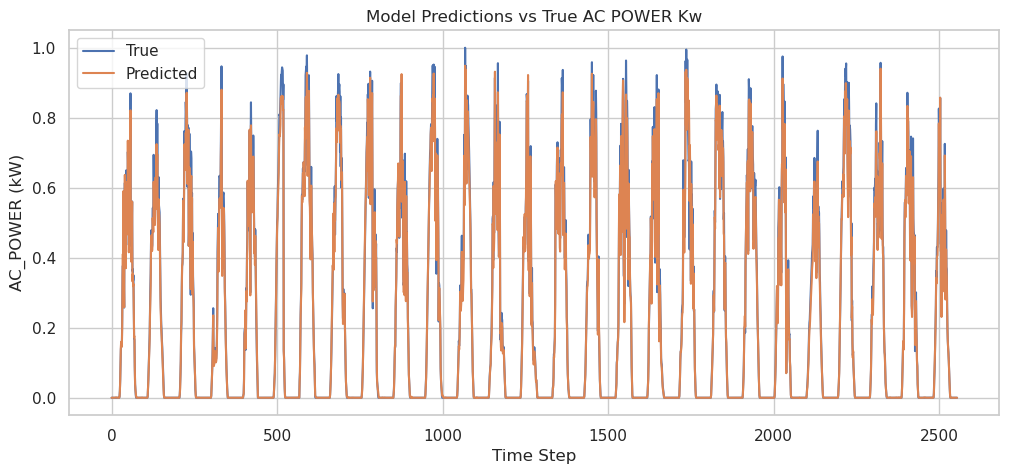

In [160]:
plt.figure(figsize=(12, 5))
plt.plot(y_train_final, label='True')
plt.plot(pred_test_final, label='Predicted')
plt.legend()
plt.title('Model Predictions vs True AC POWER Kw')
plt.xlabel('Time Step')
plt.ylabel('AC_POWER (kW)')
plt.show()

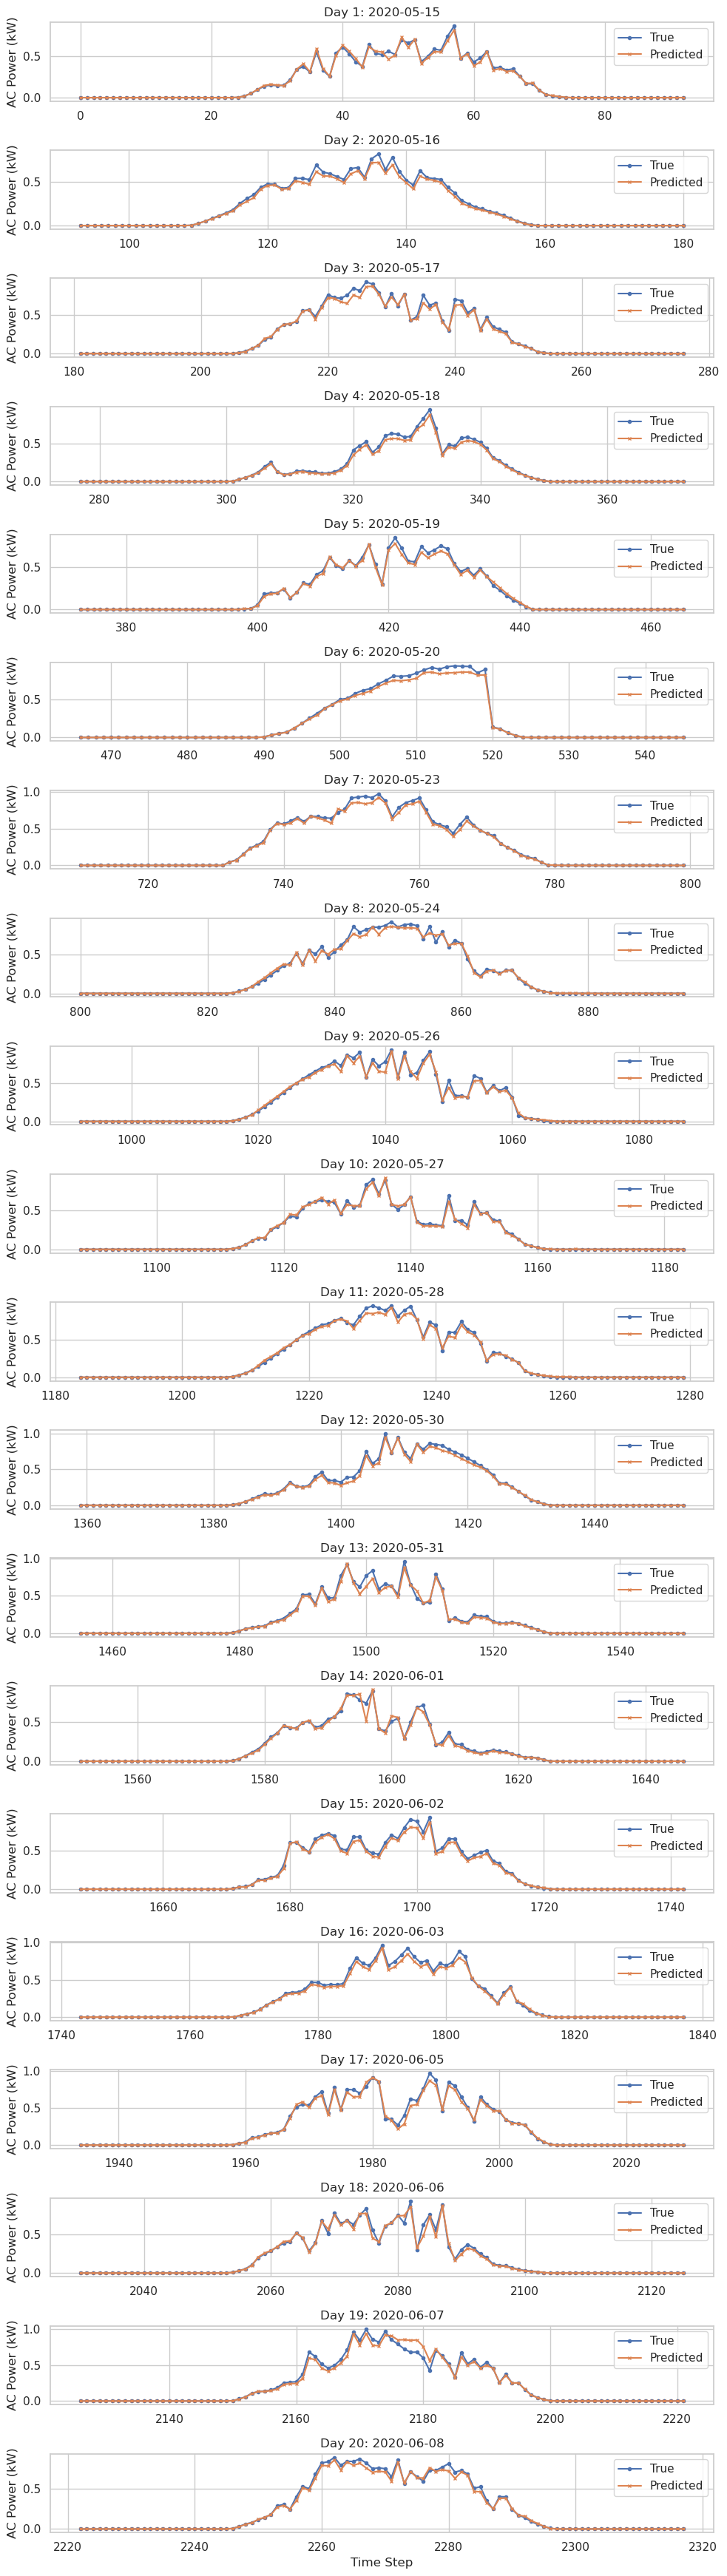

In [172]:
plot_df = train_df.copy()  # test_df contains DATE
plot_df['true'] = y_train_final
plot_df['pred'] = pred_test_final

# If you have a time column (e.g., 'TIME') you can combine with DATE
# For now, assuming DATE is enough for daily plots

# Get first 6 unique dates
unique_days = plot_df['DATE'].unique()[:20]

# Create subplots
fig, axs = plt.subplots(20, 1, figsize=(10, 35), sharex=False)

for i, day in enumerate(unique_days):
    day_data = plot_df[plot_df['DATE'] == day]
    axs[i].plot(day_data.index, day_data['true'], label='True', marker='o', markersize=3)
    axs[i].plot(day_data.index, day_data['pred'], label='Predicted', marker='x', markersize=3)
    axs[i].set_title(f'Day {i+1}: {day}')
    axs[i].set_ylabel('AC Power (kW)')
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel('Time Step')
plt.tight_layout()
plt.show()

This looks more like a balanced fit rather than overfitting. The model captures the overall pattern, smooths minor fluctuations, and doesn’t exactly mimic every peak/noise in the true data.

From the analysis we can say that our model is not overfitting. As the mean r2 difference is so low.
Also from the graph we can say that it is following the trend properly but not too much overfitting with the test dataset. Which indicates that our model is balanced fit.

# References

Stats Stack Exchange (2017). What is the meaning of "gold data"? Available at: https://stats.stackexchange.com/questions/296828/what-is-the-meaning-of-gold-data (Accessed: 21 November 2025)

ScienceDirect (n.d.) Gold Standard Data. Available at: https://www.sciencedirect.com/topics/computer-science/gold-standard-data (Accessed: 21 November 2025)

Kaggle (n.d.) Solar Power Generation Data. Available at: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data (Accessed: 21 November 2025)

Solar Panel. Available at: https://en.wikipedia.org/wiki/Solar_panel (Accessed: 21 November 2025)

United Nations Sustainable Development Goal 7: Affordable and Clean Energy. Available at: https://globalgoals.org/goals/7-affordable-and-clean-energy/ (Accessed: 21 November 2025)

The environmental factors affecting solar photovoltaic output. Available at: https://www.sciencedirect.com/science/article/pii/S1364032124007998 (Accessed: 21 November 2025)

The top 10 manufacturing companies are committed to reducing their carbon footprint. Available at: https://manufacturing-today.com/news/top-ten-manufacturing-companies-committed-to-reducing-their-carbon-footprint/ (Accessed: 21 November 2025)

Util in a software project. Available at: https://stackoverflow.com/questions/3305511/is-it-good-to-have-utils-class-in-your-software-project (Accessed: 22 November 2025)

Random Forest Regressor using Scikit Learn. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html (Accessed: 23 November 2025)

XGBoost algorithm how it works. Available at: https://www.geeksforgeeks.org/machine-learning/xgboost/ (Accessed: 23 November 2025)

Optimizing Machine Learning Models: Comparing Grid Search, Randomized Search, and Optuna. Available at : https://dev.to/iemsaad/optimizing-machine-learning-models-comparing-grid-search-randomized-search-and-optuna-4hnf#:~:text=Optuna's%20strength%20lies%20in%20its,complex%20models%20or%20large%20datasets. (Accessed: 24 November 2025)

PRACTICAL BAYESIAN OPTIMIZATION OF MACHINE LEARNING ALGORITHMS. Available at: https://arxiv.org/abs/1206.2944 (Accessed : 24 November 2025) 

Feed Forward Neural Network From Scratch. Available at: https://medium.com/@andresberejnoi/how-to-build-a-feedforward-neural-network-in-python-andres-berejnoi-a96668c025e5 (Accessed: 30 November 2025)

How To Compare Machine Learning Algorithms in Python with scikit-learn. Available at: https://machinelearningmastery.com/compare-machine-learning-algorithms-python-scikit-learn/ (Accessed: 30 November 2025)

How to perform Friedman test in python. Available at: https://www.statology.org/friedman-test-python/ (Accessed: 30 November 2025)

Cross-validation for detecting and preventing overfitting. Available at: https://www.cs.cmu.edu/afs/cs/Web/People/awm/tutorials/overfit10.pdf (Accessed: 1 December 2025)

Measuring Generalization and Overfitting in Machine Learning. Available at: https://www2.eecs.berkeley.edu/Pubs/TechRpts/2019/EECS-2019-102.pdf (Accessed: 1 December 2025)

How to Interpret Adjusted R-Squared and Predicted R-Squared in Regression Analysis. Available at: https://statisticsbyjim.com/regression/interpret-adjusted-r-squared-predicted-r-squared-regression/ (Accessed: 1 December 2025)